# Empirical Analysis of Volatility Clustering in US Equity Markets (1980-2024)

## Methodological Framework

This notebook implements a comprehensive empirical testing apparatus for examining the statistical properties of financial market returns through the lens of competing theoretical frameworks. We deploy a methodologically rigorous approach that systematically interrogates the extent to which empirical market behavior conforms to or deviates from the predictions of a properly specified Smithian model versus a behaviorally-informed extension.

The analytical architecture integrates financial econometric techniques with theoretical insights from both classical political economy and contemporary behavioral finance, enabling a nuanced assessment of market dynamics across multiple temporal stratifications and asset categories.

In [1]:
# Fixed EODHD API Configuration (Cell 2)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from datetime import datetime, timedelta
import arch
from arch.univariate import ConstantMean
from arch.univariate import GARCH as GARCH_vol, EGARCH as EGARCH_vol, FIGARCH as FIGARCH_vol
from arch.univariate import Normal, StudentsT, SkewStudent
import statsmodels.api as sm
import statsmodels.tsa.stattools as ts
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import the official EODHD API client library
from eodhd import APIClient

## Data Acquisition Configuration

Our empirical investigation employs the official EODHD Python SDK to access comprehensive financial time series data spanning multiple decades (1980-2024). This temporal scope enables robust examination of market behavior across diverse regulatory regimes and technological paradigms, providing a comprehensive empirical foundation for evaluating the competing theoretical frameworks.

The multi-tiered data acquisition strategy encompasses:
1. Market indices that provide broad cross-sectional representation
2. Sector-specific ETFs that capture domain-particular dynamics
3. Individual equities that reveal firm-level manifestations of the theoretical phenomena

In [2]:
# Configure visualization settings for academic publication
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.titlesize': 14,
    'figure.figsize': (8, 6),
    'figure.dpi': 300,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': 'lightgray',
    'grid.color': 'lightgray',
    'grid.linestyle': '--',
    'patch.edgecolor': 'darkgrey'
})

# EODHD API Configuration - Using the official APIClient class
API_KEY = os.environ.get('EODHD_API_KEY') # Get the key from environment variable

# Check if the API key is available
if not API_KEY:
    print("Warning: EODHD_API_KEY environment variable not found.")
    # Fallback to a placeholder if you want the script to run without a real key,
    # but API calls will fail. For a real run, this should be an error.
    # API_KEY = 'YOUR_API_KEY_HERE' # Replace with your actual key if not using env var
    # Or raise an error:
    raise ValueError("EODHD_API_KEY not set. Please provide a valid API key via environment variable EODHD_API_KEY.")

try:
    client = APIClient(API_KEY)
    
    # Test API connection with a simple request for a demo ticker
    test_symbol = "AAPL.US"
    print(f"Testing API connection with a simple request for {test_symbol}...")
    
    try:
        # Using the correct method name from documentation: get_eod_historical_stock_market_data
        test_result = client.get_eod_historical_stock_market_data(
            symbol=test_symbol,
            period='d',
            from_date='2023-01-01',
            to_date='2023-01-05',
            order='a'
        )
        
        if isinstance(test_result, list) and len(test_result) > 0:
            print(f"EODHD APIClient initialized successfully.")
            print(f"Sample data: Date={test_result[0].get('date', 'N/A')}, Close={test_result[0].get('close', 'N/A')}")
        else:
            print(f"Warning: API returned unexpected result: {test_result}")
            client = None  # Mark client as failed
    except Exception as e:
        print(f"API test failed: {e}")
        client = None  # Mark client as failed
except Exception as e:
    print(f"Error initializing EODHD APIClient: {e}")
    # Handle client initialization failure, perhaps by exiting or using dummy data
    client = None # Ensure client is None if initialization fails

Testing API connection with a simple request for AAPL.US...
EODHD APIClient initialized successfully.
Sample data: Date=2023-01-03, Close=125.07


In [3]:
# Data specification for multi-tiered analysis approach
MARKET_INDICES = {
    'S&P 500': 'GSPC.INDX', # Common EODHD format for US indices often does not use '^'
                            # and might use .INDX or .INDY instead of .US
                            # Verify exact EODHD tickers. Example: 'GSPC.INDX'
    'Dow Jones Industrial Average': 'DJI.INDX', # Example, verify correct EODHD ticker
    'Russell 2000': 'RUT.INDX', # Example, verify correct EODHD ticker
    'CBOE Volatility Index': 'VIX.INDX' # Example, verify correct EODHD ticker
}

SECTOR_ETFS = { # Assuming .US is correct for ETFs on EODHD
    'Financial': 'XLF.US',
    'Energy': 'XLE.US',
    'Technology': 'XLK.US',
    'Healthcare': 'XLV.US',
    'Consumer Discretionary': 'XLY.US',
    'Consumer Staples': 'XLP.US',
    'Utilities': 'XLU.US'
}

STYLE_ETFS = {
    'Growth': 'IWF.US',
    'Value': 'IWD.US',
    'Large Cap': 'IWB.US',
    'Small Cap': 'IWM.US', # This is a very common small-cap ETF
    'Volatility': 'VXX.US' # VXX is an ETN, VIXY is an ETF, ensure correct instrument
}

BLUE_CHIP_EQUITIES = { # Assuming .US is correct for US equities
    'Apple': 'AAPL.US',
    'Microsoft': 'MSFT.US',
    'Johnson & Johnson': 'JNJ.US',
    'Procter & Gamble': 'PG.US',
    'Exxon Mobil': 'XOM.US',
    'JPMorgan Chase': 'JPM.US',
    'Walmart': 'WMT.US',
    'Coca-Cola': 'KO.US',
    'IBM': 'IBM.US',
    'General Electric': 'GE.US',
    'AT&T': 'T.US',
    'Pfizer': 'PFE.US',
    'Merck': 'MRK.US',
    'Chevron': 'CVX.US',
    'Boeing': 'BA.US'
}

# Note: The EODHD ticker format for indices like S&P 500 is often 'GSPC.INDX' or similar,
# not usually with a caret ('^') and '.US'. This should be verified with EODHD documentation.
# For example, '^GSPC.US' might be Yahoo Finance format.
# I will assume the user has verified these tickers with EODHD or will adjust them.
# For the purpose of code correction, I will keep them as is but highlight this as a potential data issue.

## Temporal Stratification

To assess whether behavioral factors operate consistently across different institutional and technological regimes, we implement a temporal stratification strategy that divides the 1980-2024 analysis period into distinct sub-periods marked by major structural breaks in market history:

* **Pre-1987 Crash:** Traditional market structure with limited electronic trading
* **Post-1987 to Dot-Com:** Implementation of circuit breakers and rise of institutional trading
* **Dot-Com Bubble/Crash:** Technology-driven market speculation and subsequent correction
* **Pre-GFC Growth:** Expansion of derivatives markets and financial innovation
* **GFC Period:** Acute financial system crisis with unprecedented volatility
* **Post-GFC Recovery:** Period of quantitative easing and regulatory reform
* **COVID Period:** Pandemic-induced market disruption and policy response
* **Recent Period:** Current market dynamics with amplified retail participation

This stratification enables examination of how institutional factors may moderate but not eliminate the behavioral effects predicted by our theoretical framework.

In [4]:
# Define analysis time periods
FULL_PERIOD = {
    'start_date': '1980-01-01',
    'end_date': '2024-05-01' # Current date is 2025-05-08. Data up to 2024-05-01.
}

SUB_PERIODS = [
    {'name': 'Pre-1987 Crash', 'start_date': '1980-01-01', 'end_date': '1987-10-18'},
    {'name': 'Post-1987 to Dot-Com', 'start_date': '1987-10-19', 'end_date': '1999-12-31'},
    {'name': 'Dot-Com Bubble/Crash', 'start_date': '2000-01-01', 'end_date': '2002-12-31'},
    {'name': 'Pre-GFC Growth', 'start_date': '2003-01-01', 'end_date': '2007-10-08'},
    {'name': 'GFC Period', 'start_date': '2007-10-09', 'end_date': '2009-03-09'},
    {'name': 'Post-GFC Recovery', 'start_date': '2009-03-10', 'end_date': '2019-12-31'},
    {'name': 'COVID Period', 'start_date': '2020-01-01', 'end_date': '2022-12-31'},
    {'name': 'Recent Period', 'start_date': '2023-01-01', 'end_date': '2024-05-01'} # Matches FULL_PERIOD end_date
]

## MarketDataProcessor Class Implementation

The `MarketDataProcessor` class implements our methodological framework for financial data acquisition and analysis. This class has been redesigned to utilize the official EODHD API interface, ensuring methodological consistency and computational reproducibility while maintaining compatibility with our analytical objectives.

Key modifications include:
1. Proper implementation of the `get_historical_data` method from the EODHD Python SDK
2. Enhanced data caching mechanisms for methodological transparency
3. Robust error handling procedures for data validation and integrity verification

In [5]:
class MarketDataProcessor:
    """
    Comprehensive framework for acquiring, processing, and analyzing market data
    to test hypotheses regarding volatility clustering and market self-regulation.
    """
    
    def __init__(self, api_client, cache_dir='data_cache'):
        """Initialize the data processor with API client and cache directory."""
        if api_client is None:
            raise ValueError("APIClient cannot be None. Please provide a valid EODHD API client.")
        self.api_client = api_client
        self.cache_dir = cache_dir
        
        if self.cache_dir:
            if not os.path.exists(self.cache_dir):
                try:
                    os.makedirs(self.cache_dir)
                    print(f"Cache directory created: {self.cache_dir}")
                except OSError as e:
                    print(f"Error creating cache directory {self.cache_dir}: {e}. Caching will be disabled.")
                    self.cache_dir = None 
        else:
            print("Warning: Cache directory not specified. Caching will be disabled.")

        self.data_catalog = {} # To store metadata about fetched data
    
    def fetch_daily_data(self, symbol, start_date, end_date, use_cache=True):
        """
        Fetch daily price data for a given symbol within the specified date range.
        Uses cache when available unless explicitly disabled.
        """
        cache_file = None
        # Construct cache file path if caching is enabled and directory exists
        if use_cache and self.cache_dir: 
            # Sanitize inputs for filename
            sanitized_symbol = "".join(c if c.isalnum() else "_" for c in symbol)
            sanitized_start = start_date.replace("-", "")
            sanitized_end = end_date.replace("-", "")
            cache_file = os.path.join(self.cache_dir, 
                                    f"{sanitized_symbol}_daily_{sanitized_start}_to_{sanitized_end}.parquet")
            
            # Check if cache file exists
            if os.path.exists(cache_file):
                try:
                    df_cache = pd.read_parquet(cache_file)
                    print(f"Loaded data for {symbol} from cache: {cache_file}")
                    # Ensure index is DatetimeIndex after loading from Parquet if it's not already
                    if not isinstance(df_cache.index, pd.DatetimeIndex): 
                        df_cache.index = pd.to_datetime(df_cache.index)
                    return df_cache
                except Exception as e:
                    print(f"Error reading cache file {cache_file}: {e}. Will attempt to fetch from API.")

        # If not using cache, or cache miss/error, fetch from API
        try:
            print(f"Fetching data for {symbol} from API ({start_date} to {end_date})...")
            
            # Using the correct method name from the EODHD documentation
            # Ensure your APIClient instance has this method.
            raw_data = self.api_client.get_eod_historical_stock_market_data(
                symbol=symbol,
                period='d',      # Daily data
                from_date=start_date,
                to_date=end_date,
                order='a'        # 'a' for ascending date order, 'd' for descending
            )
            
            # Process the raw_data (assuming it's a list of dicts)
            if not raw_data or not isinstance(raw_data, list): 
                print(f"Warning: No data or unexpected data format returned by API for {symbol} from {start_date} to {end_date}. API response type: {type(raw_data)}")
                return pd.DataFrame() # Return empty DataFrame on failure

            df = pd.DataFrame(raw_data)

            if df.empty:
                print(f"Warning: API data for {symbol} ({start_date} to {end_date}) resulted in an empty DataFrame.")
                return pd.DataFrame()
            
            # Essential column check
            if 'date' not in df.columns:
                print(f"Warning: 'date' column not found in data for {symbol}. Available columns: {df.columns.tolist()}. Cannot process further.")
                return pd.DataFrame() 
                
            df['date'] = pd.to_datetime(df['date'])
            df.set_index('date', inplace=True)
            
            # Convert relevant columns to numeric, coercing errors
            cols_to_numeric = ['open', 'high', 'low', 'close', 'adjusted_close', 'volume']
            for col in cols_to_numeric:
                if col in df.columns:
                    df[col] = pd.to_numeric(df[col], errors='coerce')
            
            df.sort_index(inplace=True) # Ensure data is sorted by date
            
            # Cache the data if successful and caching is enabled
            if use_cache and cache_file: 
                try:
                    df.to_parquet(cache_file)
                    print(f"Cached data for {symbol} to {cache_file}")
                except Exception as e_cache:
                    print(f"Error caching data for {symbol} to {cache_file}: {e_cache}")
            
            # Update data catalog with metadata
            if not df.empty and isinstance(df.index, pd.DatetimeIndex):
                self.data_catalog[symbol] = {
                    'start_date': df.index.min().strftime('%Y-%m-%d'),
                    'end_date': df.index.max().strftime('%Y-%m-%d'),
                    'n_observations': len(df),
                    'cache_path': cache_file if cache_file else 'N/A' # Store cache path if used
                }
            return df
            
        except Exception as e:
            print(f"Error fetching or processing data for {symbol}: {type(e).__name__} - {str(e)}")
            # import traceback # Uncomment for debugging
            # traceback.print_exc() # Uncomment for debugging
            return pd.DataFrame() # Return empty DataFrame on error
    
    def calculate_returns(self, price_data, method='log'):
        """
        Calculate returns from price data, using either logarithmic or simple returns.
        Logarithmic returns are preferred for volatility modeling due to their 
        time-additivity properties.
        """
        if not isinstance(price_data, pd.DataFrame) or price_data.empty:
            # print("Warning: Price data is not a valid DataFrame or is empty in calculate_returns. Returning empty Series.")
            return pd.Series(dtype=float) 
        
        price_column_to_use = None
        if 'adjusted_close' in price_data.columns:
            price_column_to_use = 'adjusted_close'
        elif 'close' in price_data.columns:
            price_column_to_use = 'close'
        else:
            print(f"Error: Price data must contain 'adjusted_close' or 'close' column. Available: {price_data.columns.tolist()}")
            return pd.Series(dtype=float) 

        prices = price_data[price_column_to_use]
        prices = pd.to_numeric(prices, errors='coerce') 

        if prices.isnull().all():
            return pd.Series(dtype=float)

        returns = pd.Series(dtype=float) 
        if method == 'log':
            prices_gt_zero = prices[prices > 0]
            if prices_gt_zero.empty and not prices.empty : 
                 print(f"Warning: All prices in column '{price_column_to_use}' are non-positive. Cannot calculate log returns.")
                 return pd.Series(dtype=float)
            log_prices = np.log(prices.where(prices > 0)) 
            returns = log_prices - log_prices.shift(1)
        elif method == 'simple':
            returns = prices.pct_change()
        else:
            print(f"Error: Invalid method '{method}' for return calculation. Choose 'log' or 'simple'.")
            return pd.Series(dtype=float)
        
        return returns.dropna() 
    
    def batch_acquire_data(self, symbols_dict, period_dict, use_cache=True, show_progress=True):
        """
        Acquire data for multiple symbols over a specified period.
        Returns a dictionary mapping symbols to DataFrames with price data.
        """
        results = {}
        if not isinstance(symbols_dict, dict):
            print("Error: symbols_dict must be a dictionary.")
            return results
        if not isinstance(period_dict, dict) or 'start_date' not in period_dict or 'end_date' not in period_dict:
            print("Error: period_dict must be a dictionary with 'start_date' and 'end_date'.")
            return results

        total_symbols = len(symbols_dict)
        for i, (name, symbol_ticker) in enumerate(symbols_dict.items(), 1): 
            if show_progress:
                print(f"Fetching data for {name} ({symbol_ticker}) [{i}/{total_symbols}]...")
            
            data = self.fetch_daily_data( 
                symbol_ticker, 
                period_dict['start_date'], 
                period_dict['end_date'],
                use_cache=use_cache 
            )
            
            if data is not None and not data.empty:
                results[name] = data 
            else:
                print(f"Warning: No data acquired for {name} ({symbol_ticker}). It will be excluded from results.")
                
        return results

    def compute_return_statistics(self, returns_data):
        """
        Compute comprehensive statistics for returns data.
        """
        if not isinstance(returns_data, pd.Series):
            return self._get_empty_stats_dict(0 if returns_data is None else len(returns_data))

        numeric_returns = pd.to_numeric(returns_data, errors='coerce').dropna()
        series_name_for_logs = returns_data.name if hasattr(returns_data, 'name') and returns_data.name else 'Unnamed Series'


        if numeric_returns.empty:
            return self._get_empty_stats_dict(len(returns_data))
            
        n_obs = len(numeric_returns)
        stats_dict = self._get_empty_stats_dict(n_obs) 
        stats_dict['n_observations'] = n_obs 

        if n_obs < 4: 
            print(f"Warning: Insufficient valid data points ({n_obs}) for some statistics in {series_name_for_logs}. Results may be NaN or unreliable.")
            stats_dict['mean'] = numeric_returns.mean()
            stats_dict['std'] = numeric_returns.std()
            stats_dict['min'] = numeric_returns.min()
            stats_dict['max'] = numeric_returns.max()
            if n_obs > 0:
                stats_dict['q01'] = numeric_returns.quantile(0.01)
                stats_dict['q05'] = numeric_returns.quantile(0.05)
                stats_dict['q95'] = numeric_returns.quantile(0.95)
                stats_dict['q99'] = numeric_returns.quantile(0.99)
            return stats_dict

        # Calculate basic statistics
        stats_dict.update({
            'mean': numeric_returns.mean(),
            'std': numeric_returns.std(),
            'skewness': stats.skew(numeric_returns),
            'kurtosis': stats.kurtosis(numeric_returns, fisher=False), # Pearson's definition
            'excess_kurtosis': stats.kurtosis(numeric_returns, fisher=True), # Fisher's definition (Kurtosis - 3)
            'min': numeric_returns.min(),
            'max': numeric_returns.max(),
            'q01': numeric_returns.quantile(0.01),
            'q05': numeric_returns.quantile(0.05),
            'q95': numeric_returns.quantile(0.95),
            'q99': numeric_returns.quantile(0.99),
        })
        
        # Define std_dev_ret for Ljung-Box snippet compatibility
        std_dev_ret = stats_dict['std']

        if n_obs >= 2: 
            try:
                jb_stat, jb_pvalue = stats.jarque_bera(numeric_returns)
                stats_dict['jarque_bera'] = jb_stat
                stats_dict['jb_pvalue'] = jb_pvalue
            except Exception as e:
                 print(f"Could not compute Jarque-Bera test for {series_name_for_logs}: {e}")
        
        # Ljung-Box tests
        lags_for_lb = [10] # As per original class structure

        # ***** TARGETED LJUNG-BOX FIX/DEBUG AREA START (from ljung_box_snippet_v1) *****
        lb_stat, lb_p_value = np.nan, np.nan
        # Ensure lags_for_lb is a list and get the maximum lag value for checks
        current_max_lag = max(lags_for_lb) if isinstance(lags_for_lb, list) and lags_for_lb else (lags_for_lb if isinstance(lags_for_lb, int) else 0)

        if n_obs > current_max_lag and current_max_lag > 0: # Check n_obs > max_lag and max_lag is valid
            if std_dev_ret > 1e-10: # Check for non-constant series
                try:
                    # print(f"DEBUG: Attempting Ljung-Box for returns of {series_name_for_logs}. N_obs={n_obs}, Lags={lags_for_lb}, StdDev={std_dev_ret:.4g}")
                    # print(f"DEBUG: numeric_returns (first 5): {numeric_returns.head(5).tolist()}")
                    lb_test_result = sm.stats.acorr_ljungbox(numeric_returns, lags=lags_for_lb, return_df=True)
                    lb_stat = lb_test_result['lb_stat'].iloc[-1] 
                    lb_p_value = lb_test_result['lb_pvalue'].iloc[-1] 
                except Exception as e_lb:
                    print(f"ERROR computing Ljung-Box for returns of {series_name_for_logs}:")
                    print(f"  Exception Type: {type(e_lb).__name__}")
                    print(f"  Exception Args: {e_lb.args}")
                    # For more detailed debugging, you can uncomment the next line:
                    # traceback.print_exc()
                    lb_stat, lb_p_value = np.nan, np.nan 
            else:
                 print(f"Skipping Ljung-Box for returns of {series_name_for_logs} due to zero/low variance (StdDev ~ {std_dev_ret:.2g}).")
                 lb_stat, lb_p_value = np.nan, np.nan # Ensure NaNs are set
        elif current_max_lag > 0 : # Only print if lags were actually requested
             print(f"Skipping Ljung-Box for returns of {series_name_for_logs} due to insufficient observations ({n_obs}) for max lag {current_max_lag}.")
             lb_stat, lb_p_value = np.nan, np.nan # Ensure NaNs are set
        else: # No valid lags provided or n_obs condition not met
            lb_stat, lb_p_value = np.nan, np.nan


        lb_sq_stat, lb_sq_p_value = np.nan, np.nan
        squared_returns = numeric_returns**2
        if n_obs > current_max_lag and current_max_lag > 0: # Check n_obs > max_lag and max_lag is valid
            if squared_returns.std() > 1e-10: # Check for non-constant squared series
                try:
                    # print(f"DEBUG: Attempting Ljung-Box for squared returns of {series_name_for_logs}. N_obs={n_obs}, Lags={lags_for_lb}, StdDevSq={squared_returns.std():.4g}")
                    # print(f"DEBUG: squared_returns (first 5): {squared_returns.head(5).tolist()}")
                    lb_sq_test_result = sm.stats.acorr_ljungbox(squared_returns, lags=lags_for_lb, return_df=True)
                    lb_sq_stat = lb_sq_test_result['lb_stat'].iloc[-1]
                    lb_sq_p_value = lb_sq_test_result['lb_pvalue'].iloc[-1]
                except Exception as e_lbsq:
                    print(f"ERROR computing Ljung-Box for squared returns of {series_name_for_logs}:")
                    print(f"  Exception Type: {type(e_lbsq).__name__}")
                    print(f"  Exception Args: {e_lbsq.args}")
                    # For more detailed debugging, you can uncomment the next line:
                    # traceback.print_exc()
                    lb_sq_stat, lb_sq_p_value = np.nan, np.nan
            else:
                print(f"Skipping Ljung-Box for squared returns of {series_name_for_logs} due to zero/low variance of squared returns (StdDevSq ~ {squared_returns.std():.2g}).")
                lb_sq_stat, lb_sq_p_value = np.nan, np.nan # Ensure NaNs are set
        elif current_max_lag > 0: # Only print if lags were actually requested
            print(f"Skipping Ljung-Box for squared returns of {series_name_for_logs} due to insufficient observations ({n_obs}) for max lag {current_max_lag}.")
            lb_sq_stat, lb_sq_p_value = np.nan, np.nan # Ensure NaNs are set
        else: # No valid lags provided or n_obs condition not met
            lb_sq_stat, lb_sq_p_value = np.nan, np.nan
        # ***** TARGETED LJUNG-BOX FIX/DEBUG AREA END *****

        # Update stats_dict with results from the Ljung-Box snippet
        stats_dict['ljung_box_10'] = lb_stat
        stats_dict['lb_10_pvalue'] = lb_p_value
        stats_dict['ljung_box_squared_10'] = lb_sq_stat
        stats_dict['lb_squared_10_pvalue'] = lb_sq_p_value
        
        # ARCH-LM test
        nlags_arch = 10 # As per original class structure
        if n_obs > nlags_arch:
            try:
                # Ensure numeric_returns is 1D array for het_arch if it's a Series
                arch_lm_input = numeric_returns.values if isinstance(numeric_returns, pd.Series) else numeric_returns
                arch_lm_results = sm.stats.diagnostic.het_arch(arch_lm_input, nlags=nlags_arch, store=False, ddof=0)
                stats_dict['arch_lm_stat'] = arch_lm_results[0]
                stats_dict['arch_lm_pvalue'] = arch_lm_results[1]
            except Exception as e:
                print(f"Could not compute ARCH-LM test for {series_name_for_logs}: {e}")
            
        return stats_dict

    def _get_empty_stats_dict(self, n_observations_initial):
        """Helper to return a stats dict initialized with NaNs."""
        return {
            'mean': np.nan, 'std': np.nan, 'skewness': np.nan, 'kurtosis': np.nan,
            'excess_kurtosis': np.nan, 'min': np.nan, 'max': np.nan,
            'q01': np.nan, 'q05': np.nan, 'q95': np.nan, 'q99': np.nan,
            'jarque_bera': np.nan, 'jb_pvalue': np.nan,
            'ljung_box_10': np.nan, 'lb_10_pvalue': np.nan,
            'ljung_box_squared_10': np.nan, 'lb_squared_10_pvalue': np.nan,
            'arch_lm_stat': np.nan, 'arch_lm_pvalue': np.nan,
            'n_observations': n_observations_initial 
        }

    def _calculate_persistence(self, fitted_model, model_name_simple):
        """
        Helper function to calculate persistence for different GARCH models.
        model_name_simple should be 'GARCH', 'GJR', 'EGARCH', 'FIGARCH'.
        """
        params = fitted_model.params
        persistence = np.nan 

        try:
            if model_name_simple == 'GARCH': 
                alpha_sum = sum(v for k, v in params.items() if k.startswith('alpha'))
                beta_sum = sum(v for k, v in params.items() if k.startswith('beta'))
                persistence = alpha_sum + beta_sum
            elif model_name_simple == 'GJR': 
                alpha_sum = sum(v for k, v in params.items() if k.startswith('alpha'))
                beta_sum = sum(v for k, v in params.items() if k.startswith('beta'))
                gamma_sum = sum(v for k, v in params.items() if k.startswith('gamma'))
                persistence = alpha_sum + beta_sum + 0.5 * gamma_sum
            elif model_name_simple == 'EGARCH':
                if hasattr(fitted_model, 'persistence') and callable(fitted_model.persistence):
                     persistence = fitted_model.persistence()
                else: 
                    beta_sum = sum(v for k, v in params.items() if k.startswith('beta'))
                    persistence = beta_sum 
            elif model_name_simple == 'FIGARCH':
                if 'd' in params:
                    persistence = params['d']
            else:
                print(f"Unknown model_name_simple '{model_name_simple}' for persistence calculation.")

        except KeyError as e:
            print(f"KeyError calculating persistence for {model_name_simple}: {e}. Parameters available: {list(params.keys()) if params is not None else 'None'}")
        except Exception as e:
            print(f"General error calculating persistence for {model_name_simple}: {e}")
            
        return persistence

    def estimate_garch_models(self, returns, models_to_run=['GARCH', 'GJR', 'EGARCH', 'FIGARCH'], 
                              distributions_to_run=['normal', 'studentst', 'skewt'], 
                              p_lag=1, q_lag=1, o_lag=1): 
        """
        Estimate multiple GARCH-family models on returns data.
        """
        if not isinstance(returns, pd.Series):
            print("Error: `returns` must be a pandas Series for GARCH estimation.")
            return {'error': 'Input not a pandas Series', 'best_model_overall': None}
        
        scaled_returns = returns.dropna() * 100 

        if len(scaled_returns) < 100: 
            print(f"Warning: Insufficient data points ({len(scaled_returns)}) for reliable GARCH estimation. Min 100 recommended.")
            return {'warning': 'Insufficient data', 'best_model_overall': None}
        
        estimation_results = {}
        
        # Corrected to use SkewStudent which is standard in `arch`
        dist_map = {
            'normal': Normal(),
            'studentst': StudentsT(),
            'skewt': SkewStudent() # Changed from SkewedT
        }
        
        for model_name_simple in models_to_run:
            for dist_name in distributions_to_run:
                # Determine o_lag for naming, only if model uses it
                o_lag_in_name = o_lag if model_name_simple in ['GJR', 'EGARCH'] else 0
                spec_key_name = f"{model_name_simple}({p_lag},{o_lag_in_name},{q_lag})-{dist_name}"
                
                current_dist_obj = dist_map.get(dist_name)
                if current_dist_obj is None:
                    print(f"Warning: Unknown distribution '{dist_name}'. Skipping {spec_key_name}.")
                    continue

                if model_name_simple == 'FIGARCH' and dist_name == 'skewt': # 'skewt' maps to SkewStudent
                    print(f"Skipping FIGARCH with SkewStudent ({spec_key_name}) due to potential convergence issues.")
                    continue
                
                try:
                    model_spec = ConstantMean(scaled_returns) 
                    model_spec.distribution = current_dist_obj

                    if model_name_simple == 'GARCH':
                        model_spec.volatility = GARCH_vol(p=p_lag, o=0, q=q_lag) # o=0 for standard GARCH
                    elif model_name_simple == 'GJR': 
                        model_spec.volatility = GARCH_vol(p=p_lag, o=o_lag, q=q_lag) 
                    elif model_name_simple == 'EGARCH':
                        model_spec.volatility = EGARCH_vol(p=p_lag, o=o_lag, q=q_lag) 
                    elif model_name_simple == 'FIGARCH':
                        model_spec.volatility = FIGARCH_vol(p=p_lag, q=q_lag) 
                    else:
                        print(f"Warning: Unknown GARCH model type '{model_name_simple}'. Skipping {spec_key_name}.")
                        continue
                    
                    print(f"Estimating {spec_key_name}...")
                    
                    fitted_model_result = model_spec.fit(disp='off', show_warning=False)
                    
                    persistence_val = self._calculate_persistence(fitted_model_result, model_name_simple)

                    estimation_results[spec_key_name] = {
                        'model_object': fitted_model_result, 
                        'aic': fitted_model_result.aic,
                        'bic': fitted_model_result.bic,
                        'loglikelihood': fitted_model_result.loglikelihood,
                        'parameters': dict(fitted_model_result.params),
                        'persistence': persistence_val,
                        'pvalues': dict(fitted_model_result.pvalues),
                        'summary': str(fitted_model_result.summary()) 
                    }
                    
                    if 'nu' in fitted_model_result.params: 
                         estimation_results[spec_key_name]['nu'] = fitted_model_result.params['nu']
                    if 'lambda' in fitted_model_result.params: 
                        estimation_results[spec_key_name]['lambda'] = fitted_model_result.params['lambda']
                
                except Exception as e:
                    print(f"Error estimating {spec_key_name}: {type(e).__name__} - {str(e)}")
                    estimation_results[spec_key_name] = {'error': str(e), 'error_type': type(e).__name__}
                    continue 
        
        successful_fits = {k: v for k, v in estimation_results.items() if 'aic' in v and v['aic'] is not np.nan}
        if successful_fits:
            best_model_name = min(successful_fits, key=lambda k: successful_fits[k]['aic'])
            estimation_results['best_model_overall'] = {
                'name': best_model_name,
                **successful_fits[best_model_name] 
            }
            if 'model_object' in estimation_results['best_model_overall']:
                del estimation_results['best_model_overall']['model_object']
        else:
            estimation_results['best_model_overall'] = None
            print("No GARCH models were estimated successfully.")
            
        return estimation_results

    def estimate_hyperbolic_decay(self, returns, max_lag=100, plot_figure=True):
        """
        Estimate the hyperbolic decay pattern in absolute returns autocorrelation.
        """
        if not isinstance(returns, pd.Series):
            print("Error: `returns` must be a pandas Series for hyperbolic decay estimation.")
            return {
                'intercept': np.nan, 'power_law_exponent': np.nan, 'r_squared': np.nan,
                'acf_values': np.array([]), 'lags': np.array([]), 'figure': None,
                'error': 'Input was not a pandas Series.'
            }

        abs_returns = np.abs(returns.dropna()) 

        if abs_returns.empty:
            print("Warning: Absolute returns data is empty. Cannot estimate hyperbolic decay.")
            return {
                'intercept': np.nan, 'power_law_exponent': np.nan, 'r_squared': np.nan,
                'acf_values': np.array([]), 'lags': np.array([]), 'figure': None,
                'error': 'Absolute returns data empty.'
            }
        
        current_max_lag = max_lag
        if len(abs_returns) <= current_max_lag:
            print(f"Warning: Length of absolute returns ({len(abs_returns)}) is less than or equal to max_lag ({current_max_lag}). Reducing max_lag.")
            current_max_lag = max(1, len(abs_returns) - 2) 
            if current_max_lag == 0 :
                 print("Error: Not enough data points to calculate ACF for hyperbolic decay after adjustment.")
                 return { 'intercept': np.nan, 'power_law_exponent': np.nan, 'r_squared': np.nan,
                          'acf_values': np.array([]), 'lags': np.array([]), 'figure': None,
                          'error': 'Not enough data for ACF.'}
        
        fig_to_return = None 

        try:
            acf_results = sm.tsa.acf(abs_returns, nlags=current_max_lag, fft=True, alpha=None) 
            lags_arr = np.arange(1, current_max_lag + 1) 
            acf_values_arr = acf_results[1:current_max_lag + 1] 

            positive_acf_indices = acf_values_arr > 1e-10 
            if not np.any(positive_acf_indices):
                print("Warning: All ACF values (lag > 0) are non-positive. Cannot perform log-log regression.")
                # Still attempt to plot if requested, even if regression fails
                if plot_figure:
                    try:
                        fig, ax1 = plt.subplots(1, 1, figsize=(7, 6)) # Only ACF plot
                        ax1.stem(lags_arr, acf_values_arr, linefmt='grey', markerfmt='o', basefmt=" ")
                        ax1.set_xlabel('Lag')
                        ax1.set_ylabel('ACF of Absolute Returns')
                        ax1.set_title(f'ACF (Max Lag: {current_max_lag}) - No Positive Values for Regression')
                        ax1.grid(True, alpha=0.3)
                        plt.tight_layout()
                        fig_to_return = fig
                    except Exception as e_plot_fail:
                        print(f"Error generating ACF plot (no positive values case): {e_plot_fail}")
                        if fig_to_return: plt.close(fig_to_return)
                        fig_to_return = None

                return {
                    'intercept': np.nan, 'power_law_exponent': np.nan, 'r_squared': np.nan,
                    'acf_values': acf_values_arr, 'lags': lags_arr, 'figure': fig_to_return, 
                    'error': 'No positive ACF values for log-log regression.'
                }

            log_lags_reg = np.log(lags_arr[positive_acf_indices])
            log_acf_reg = np.log(acf_values_arr[positive_acf_indices])
            
            X_reg = sm.add_constant(log_lags_reg) 
            ols_model = sm.OLS(log_acf_reg, X_reg)
            ols_fitted_results = ols_model.fit()
            
            intercept_val = ols_fitted_results.params[0]
            slope_val = ols_fitted_results.params[1]  
            r_squared_val = ols_fitted_results.rsquared
            
        except Exception as e:
            print(f"Error during hyperbolic decay OLS estimation: {type(e).__name__} - {str(e)}")
            return {
                'intercept': np.nan, 'power_law_exponent': np.nan, 'r_squared': np.nan,
                'acf_values': acf_results[1:current_max_lag + 1] if 'acf_results' in locals() and acf_results is not None else np.array([]), 
                'lags': lags_arr if 'lags_arr' in locals() else np.array([]), 
                'figure': fig_to_return, 'error': str(e)
            }

        if plot_figure: # This part executes if OLS was successful
            try:
                plot_lags = lags_arr
                plot_acf_values = acf_values_arr
                # Use the same log_lags_reg and log_acf_reg that were used in the regression
                # This ensures the plot matches the regression data points.
                
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
                
                ax1.stem(plot_lags, plot_acf_values, linefmt='grey', markerfmt='o', basefmt=" ")
                ax1.set_xlabel('Lag')
                ax1.set_ylabel('ACF of Absolute Returns')
                ax1.set_title(f'ACF (Max Lag: {current_max_lag})')
                ax1.grid(True, alpha=0.3)
                
                ax2.scatter(log_lags_reg, log_acf_reg, alpha=0.6, s=30, label='Empirical Log(ACF)')
                ax2.plot(log_lags_reg, intercept_val + slope_val * log_lags_reg, 'r-', linewidth=2, 
                         label=f'OLS Fit (Slope={slope_val:.3f})')
                ax2.set_xlabel('Log(Lag)')
                ax2.set_ylabel('Log(ACF of Absolute Returns)')
                ax2.set_title(f'Log-Log Regression: Slope = {slope_val:.3f}, R² = {r_squared_val:.3f}')
                ax2.legend()
                ax2.grid(True, alpha=0.3)
                
                plt.tight_layout()
                fig_to_return = fig 
            except Exception as e_plot:
                print(f"Error generating plot for hyperbolic decay: {e_plot}")
                if fig_to_return: plt.close(fig_to_return) 
                fig_to_return = None

        return {
            'intercept': intercept_val,
            'power_law_exponent': slope_val,
            'r_squared': r_squared_val,
            'acf_values': acf_values_arr, 
            'lags': lags_arr,       
            'figure': fig_to_return
        }

    def analyze_tail_risk(self, returns, benchmark_dist_name='normal', plot_figure=True):
        """
        Analyze and visualize tail risk properties of returns distribution.
        """
        if not isinstance(returns, pd.Series):
            print("Error: `returns` must be a pandas Series for tail risk analysis.")
            return {
                'error': 'Input was not a pandas Series.', 'figure': None,
                'left_tail_mean_ratio': np.nan, 'right_tail_mean_ratio': np.nan,
                'left_tail_max_deviation_from_1': np.nan, 'right_tail_max_deviation_from_1': np.nan,
            }

        cleaned_returns = returns.dropna()
        if cleaned_returns.empty:
            print("Warning: Returns data is empty after dropping NaNs. Cannot analyze tail risk.")
            return {
                'error': 'Returns data empty after NaNs.', 'figure': None,
                'left_tail_mean_ratio': np.nan, 'right_tail_mean_ratio': np.nan,
                'left_tail_max_deviation_from_1': np.nan, 'right_tail_max_deviation_from_1': np.nan,
            }

        if len(cleaned_returns) < 10: 
            print(f"Warning: Very few data points ({len(cleaned_returns)}) for tail risk analysis. Results might be unreliable.")
            return {
                'error': f'Insufficient data points ({len(cleaned_returns)}) for reliable tail risk analysis.', 
                'figure': None,
                'left_tail_mean_ratio': np.nan, 'right_tail_mean_ratio': np.nan,
                'left_tail_max_deviation_from_1': np.nan, 'right_tail_max_deviation_from_1': np.nan,
            }

        quantiles_to_calc = np.arange(0.01, 1.00, 0.01) 
        empirical_q_values = cleaned_returns.quantile(quantiles_to_calc)
        theoretical_q_values = np.full_like(quantiles_to_calc, np.nan, dtype=float) 
        fitted_dist_params = {} 

        try:
            if benchmark_dist_name.lower() == 'normal':
                loc, scale = stats.norm.fit(cleaned_returns)
                theoretical_q_values = stats.norm.ppf(quantiles_to_calc, loc=loc, scale=scale)
                fitted_dist_params = {'loc': loc, 'scale': scale}
            elif benchmark_dist_name.lower() == 'studentt':
                try:
                    df_param, loc, scale = stats.t.fit(cleaned_returns)
                    if df_param > 200: 
                        print(f"Fitted Student's t df ({df_param:.2f}) is very large, distribution is close to normal.")
                    theoretical_q_values = stats.t.ppf(quantiles_to_calc, df=df_param, loc=loc, scale=scale)
                    fitted_dist_params = {'df': df_param, 'loc': loc, 'scale': scale}
                    print(f"Fitted Student's t: df={df_param:.2f}, loc={loc:.4f}, scale={scale:.4f}")
                except Exception as e_tfit:
                    print(f"Warning: Failed to fit Student's t distribution: {e_tfit}. Falling back to Normal.")
                    benchmark_dist_name = 'normal' 
                    loc, scale = stats.norm.fit(cleaned_returns)
                    theoretical_q_values = stats.norm.ppf(quantiles_to_calc, loc=loc, scale=scale)
                    fitted_dist_params = {'loc': loc, 'scale': scale, 'fallback_reason': str(e_tfit)}
            else:
                raise ValueError(f"Unknown benchmark distribution: {benchmark_dist_name}. Choose 'normal' or 'studentt'.")
        except Exception as e_dist_fit:
            print(f"Error during distribution fitting or ppf calculation: {e_dist_fit}")
            return {
                'error': str(e_dist_fit), 'figure': None,
                'left_tail_mean_ratio': np.nan, 'right_tail_mean_ratio': np.nan,
                'left_tail_max_deviation_from_1': np.nan, 'right_tail_max_deviation_from_1': np.nan,
            }

        num_quantile_points = len(quantiles_to_calc)
        tail_size_idx = max(1, int(num_quantile_points * 0.05)) 

        left_tail_q_indices = slice(0, tail_size_idx)
        right_tail_q_indices = slice(num_quantile_points - tail_size_idx, num_quantile_points)

        emp_left_tail = empirical_q_values.iloc[left_tail_q_indices]
        emp_right_tail = empirical_q_values.iloc[right_tail_q_indices]
        theo_left_tail = theoretical_q_values[left_tail_q_indices]
        theo_right_tail = theoretical_q_values[right_tail_q_indices]

        # Ensure denominators are not zero and are finite before division
        safe_theo_left_tail = np.where((theo_left_tail != 0) & np.isfinite(theo_left_tail), theo_left_tail, np.nan)
        safe_theo_right_tail = np.where((theo_right_tail != 0) & np.isfinite(theo_right_tail), theo_right_tail, np.nan)

        left_tail_ratio_series = pd.Series(emp_left_tail.values / safe_theo_left_tail, index=emp_left_tail.index)
        right_tail_ratio_series = pd.Series(emp_right_tail.values / safe_theo_right_tail, index=emp_right_tail.index)
        
        left_tail_ratio_series.replace([np.inf, -np.inf], np.nan, inplace=True)
        right_tail_ratio_series.replace([np.inf, -np.inf], np.nan, inplace=True)
        
        valid_left_ratios = left_tail_ratio_series.dropna()
        valid_right_ratios = right_tail_ratio_series.dropna()

        analysis_summary = {
            'left_tail_mean_ratio': valid_left_ratios.mean() if not valid_left_ratios.empty else np.nan,
            'right_tail_mean_ratio': valid_right_ratios.mean() if not valid_right_ratios.empty else np.nan,
            'left_tail_max_deviation_from_1': abs(valid_left_ratios - 1).max() if not valid_left_ratios.empty else np.nan,
            'right_tail_max_deviation_from_1': abs(valid_right_ratios - 1).max() if not valid_right_ratios.empty else np.nan,
            'empirical_quantiles_map': dict(zip(quantiles_to_calc, empirical_q_values.values)), # Ensure values are extracted
            'theoretical_quantiles_map': dict(zip(quantiles_to_calc, theoretical_q_values)),
            'fitted_dist_params': fitted_dist_params,
            'figure': None 
        }

        fig_to_return = None
        if plot_figure:
            try:
                fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
                
                ax1.scatter(theoretical_q_values, empirical_q_values, alpha=0.7, s=30, label='Empirical Q')
                combined_q_values = np.concatenate([theoretical_q_values, empirical_q_values.values])
                valid_q_values = combined_q_values[np.isfinite(combined_q_values)]
                if len(valid_q_values)>0:
                    min_val = np.min(valid_q_values)
                    max_val = np.max(valid_q_values)
                    ax1.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='y=x line')

                ax1.set_xlabel(f'Theoretical Quantiles ({benchmark_dist_name.capitalize()})')
                ax1.set_ylabel('Empirical Quantiles')
                ax1.set_title(f'QQ Plot vs. {benchmark_dist_name.capitalize()}')
                ax1.legend()
                ax1.grid(True, alpha=0.3)
                
                # Plotting tail ratios - ensure indices align if NaNs were dropped
                # Get the original quantiles that correspond to the valid ratios
                left_plot_quantiles = quantiles_to_calc[left_tail_q_indices][valid_left_ratios.index.dropna()] if not valid_left_ratios.empty else np.array([])
                right_plot_quantiles = quantiles_to_calc[right_tail_q_indices][valid_right_ratios.index.dropna()] if not valid_right_ratios.empty else np.array([])

                if len(left_plot_quantiles) == len(valid_left_ratios):
                    ax2.plot(left_plot_quantiles, valid_left_ratios.values, 
                             'b-o', linewidth=1.5, markersize=4, label='Left Tail Ratio')
                if len(right_plot_quantiles) == len(valid_right_ratios):
                    ax2.plot(right_plot_quantiles, valid_right_ratios.values, 
                             'r-o', linewidth=1.5, markersize=4, label='Right Tail Ratio')
                
                ax2.axhline(y=1, color='k', linestyle='--', alpha=0.7, label='Ratio = 1')
                ax2.set_xlabel('Quantile')
                ax2.set_ylabel('Empirical / Theoretical Quantile Ratio')
                ax2.set_title('Tail Risk Ratios')
                if not valid_left_ratios.empty or not valid_right_ratios.empty :
                    ax2.legend()
                ax2.grid(True, alpha=0.3)

                plt.tight_layout()
                fig_to_return = fig
            except Exception as e_plot:
                print(f"Error generating plot for tail risk: {e_plot}")
                if fig_to_return: plt.close(fig_to_return) 
                fig_to_return = None
        
        analysis_summary['figure'] = fig_to_return # Update the summary with the figure
        return analysis_summary

    def run_complete_analysis(self, symbols_dict, analysis_name='Default Analysis', 
                              period_dict=None, sub_periods_list=None, 
                              garch_models_to_run=['GJR', 'GARCH'], 
                              garch_distributions_to_run=['studentst', 'normal'], 
                              p_lag=1, q_lag=1, o_lag=1, 
                              plot_individual_decay_acf=False, 
                              plot_individual_tail_risk=False
                             ):
        """
        Run comprehensive analysis for a set of symbols over specified periods.
        """
        if period_dict is None: 
            # Attempt to use a globally defined FULL_PERIOD if available
            # This is not ideal; prefer passing period_dict explicitly.
            global FULL_PERIOD 
            if 'FULL_PERIOD' in globals() and isinstance(FULL_PERIOD, dict) and \
               'start_date' in FULL_PERIOD and 'end_date' in FULL_PERIOD:
                period_dict = FULL_PERIOD
                print(f"Using global FULL_PERIOD: {period_dict}")
            else:
                current_date_str = datetime.date.today().strftime('%Y-%m-%d') # Corrected datetime.now() to datetime.date.today()
                period_dict = {'start_date':'1990-01-01', 'end_date': current_date_str}
                print(f"Warning: FULL_PERIOD not properly defined or period_dict not provided. Using default period: {period_dict}")

        master_results = {
            'analysis_name': analysis_name,
            'target_symbols_map': symbols_dict,
            'main_analysis_period': period_dict,
            'analysis_execution_time': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'), # Corrected datetime.now()
            'asset_results': {}
        }
        
        print(f"\n=== Starting Analysis: {analysis_name} ===")
        print(f"Period: {period_dict['start_date']} to {period_dict['end_date']}")
        
        all_raw_data = self.batch_acquire_data(symbols_dict, period_dict, use_cache=True, show_progress=True)
        
        if not all_raw_data:
            print(f"No data acquired for any symbols in {analysis_name}. Ending analysis.")
            return master_results

        for display_name, raw_asset_data in all_raw_data.items():
            ticker_symbol = symbols_dict.get(display_name, "Unknown Ticker") 
            print(f"\n--- Analyzing Asset: {display_name} ({ticker_symbol}) ---")
            
            returns_full_period = self.calculate_returns(raw_asset_data, method='log')
            
            min_obs_for_analysis = 50 
            if returns_full_period.empty or len(returns_full_period) < min_obs_for_analysis:
                print(f"Warning: Insufficient return data for {display_name} ({len(returns_full_period)} points). Skipping detailed analysis.")
                master_results['asset_results'][display_name] = {
                    'ticker': ticker_symbol,
                    'status': 'Insufficient data for full analysis',
                    'n_observations_returns': len(returns_full_period)
                }
                continue
            
            current_asset_results = {
                'ticker': ticker_symbol,
                'full_period_details': {
                    'start_date': returns_full_period.index.min().strftime('%Y-%m-%d') if not returns_full_period.empty else 'N/A', # Add check
                    'end_date': returns_full_period.index.max().strftime('%Y-%m-%d') if not returns_full_period.empty else 'N/A', # Add check
                    'n_observations': len(returns_full_period)
                }
            }
            
            print(f"Computing return statistics for {display_name} (Full Period)...")
            current_asset_results['statistics_full_period'] = self.compute_return_statistics(returns_full_period)
            
            print(f"Estimating GARCH models for {display_name} (Full Period)...")
            current_asset_results['garch_models_full_period'] = self.estimate_garch_models(
                returns_full_period, 
                models_to_run=garch_models_to_run, 
                distributions_to_run=garch_distributions_to_run,
                p_lag=p_lag, q_lag=q_lag, o_lag=o_lag 
            )
            
            print(f"Analyzing autocorrelation decay for {display_name} (Full Period)...")
            decay_results = self.estimate_hyperbolic_decay(
                returns_full_period, plot_figure=plot_individual_decay_acf
            )
            current_asset_results['hyperbolic_decay_full_period'] = decay_results
            if plot_individual_decay_acf and decay_results.get('figure'):
                plt.show() # Or handle figure saving/display as needed
            elif decay_results.get('figure'): # Close if not shown
                plt.close(decay_results['figure'])


            print(f"Analyzing tail risk for {display_name} (Full Period)...")
            tail_results = self.analyze_tail_risk(
                returns_full_period, plot_figure=plot_individual_tail_risk
            )
            current_asset_results['tail_risk_full_period'] = tail_results
            if plot_individual_tail_risk and tail_results.get('figure'):
                plt.show()
            elif tail_results.get('figure'):
                plt.close(tail_results['figure'])

            
            if sub_periods_list and isinstance(sub_periods_list, list):
                current_asset_results['sub_period_analysis'] = {}
                print(f"\n-- Sub-period analysis for {display_name} --")
                for sub_period_info in sub_periods_list:
                    period_name = sub_period_info.get('name', 'Unknown Sub-Period')
                    start_sp = sub_period_info.get('start_date')
                    end_sp = sub_period_info.get('end_date')

                    if not (start_sp and end_sp):
                        print(f"Warning: Invalid sub-period info for {period_name}. Skipping.")
                        continue
                        
                    print(f"Analyzing sub-period: {period_name} ({start_sp} to {end_sp})...")
                    
                    try:
                        start_sp_dt = pd.to_datetime(start_sp)
                        end_sp_dt = pd.to_datetime(end_sp)
                        period_returns = returns_full_period.loc[start_sp_dt:end_sp_dt]
                    except Exception as e_filter:
                        print(f"Error filtering returns for sub-period {period_name} ({display_name}): {e_filter}")
                        period_returns = pd.Series(dtype=float)

                    min_obs_sub_period_stats = 30
                    min_obs_sub_period_garch = 100

                    if period_returns.empty or len(period_returns) < min_obs_sub_period_stats:
                        print(f"Warning: Insufficient data in sub-period {period_name} for {display_name} ({len(period_returns)} points). Skipping detailed sub-analysis.")
                        current_asset_results['sub_period_analysis'][period_name] = {
                            'status': 'Insufficient data for stats', 'n_observations': len(period_returns)
                        }
                        continue
                    
                    sub_period_data_dict = {
                        'start_date': period_returns.index.min().strftime('%Y-%m-%d') if not period_returns.empty else start_sp, # Add check
                        'end_date': period_returns.index.max().strftime('%Y-%m-%d') if not period_returns.empty else end_sp, # Add check
                        'n_observations': len(period_returns),
                        'statistics': self.compute_return_statistics(period_returns)
                    }
                    
                    if len(period_returns) >= min_obs_sub_period_garch:
                         print(f"Estimating GARCH for sub-period {period_name} ({display_name})...")
                         sub_period_data_dict['garch_models'] = self.estimate_garch_models(
                             period_returns,
                             models_to_run=garch_models_to_run, 
                             distributions_to_run=garch_distributions_to_run,
                             p_lag=p_lag, q_lag=q_lag, o_lag=o_lag 
                         )
                    else:
                        sub_period_data_dict['garch_models'] = {'status': f'Skipped GARCH, N={len(period_returns)} < {min_obs_sub_period_garch}'}

                    current_asset_results['sub_period_analysis'][period_name] = sub_period_data_dict
            
            master_results['asset_results'][display_name] = current_asset_results
        
        print(f"\n=== Analysis Complete: {analysis_name} ===")
        return master_results



## Results Visualization Framework

The `ResultsVisualizer` class implements specialized techniques for communicating our empirical findings through publication-quality visualizations. These methods enable systematic cross-comparison of key metrics across assets and time periods, facilitating identification of patterns consistent with our theoretical hypotheses.

Each visualization method generates standardized outputs with consistent formatting, enabling direct comparison across asset classes and time periods. The results are automatically saved in a structured directory hierarchy, facilitating inclusion in scholarly publications.

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class ResultsVisualizer:
    """
    Tools for visualizing and interpreting the results of volatility clustering analysis,
    focused on generating publication-quality figures that communicate key empirical findings.
    """
    
    def __init__(self, output_dir='figures'):
        """Initialize the visualizer with output directory."""
        self.output_dir = output_dir
        
        if self.output_dir:
            if not os.path.exists(self.output_dir):
                try:
                    os.makedirs(self.output_dir)
                    print(f"Output directory created: {self.output_dir}")
                except OSError as e:
                    print(f"Error creating output directory {self.output_dir}: {e}. Figures may not be saved.")
                    self.output_dir = None 
        else:
            print("Warning: No output directory specified for ResultsVisualizer. Figures will not be saved by default.")
            self.output_dir = None

    def _save_and_show_plot(self, fig, filename_prefix, group_name, show_fig=True):
        """Helper function to save and optionally show a plot."""
        if fig is None:
            print(f"No figure object to save for {filename_prefix}_{group_name}")
            return

        if self.output_dir:
            try:
                filename = os.path.join(self.output_dir, f'{filename_prefix}_{group_name.replace(" ", "_").lower()}.png')
                fig.savefig(filename, dpi=300, bbox_inches='tight')
                print(f"Plot saved to: {filename}")
            except Exception as e:
                print(f"Error saving plot {filename}: {e}")
        
        if show_fig:
            plt.show()
        else:
            plt.close(fig) # Close the figure if not shown to free memory

    def compare_kurtosis(self, analysis_results_dict, group_name='Market_Analysis', save_fig=True, show_fig=True):
        """
        Compare kurtosis values across different assets to assess fat-tailedness.
        Uses Pearson's kurtosis (Normal = 3).
        """
        if 'asset_results' not in analysis_results_dict:
            print("Error: 'asset_results' key not found in analysis_results_dict.")
            return None

        assets_data = []
        for asset_display_name, asset_data_dict in analysis_results_dict['asset_results'].items():
            if 'statistics_full_period' in asset_data_dict and asset_data_dict['statistics_full_period']:
                stats = asset_data_dict['statistics_full_period']
                kurt_val = stats.get('kurtosis', np.nan) 
                if pd.notna(kurt_val):
                    assets_data.append({'asset': asset_display_name, 'kurtosis': kurt_val})
        
        if not assets_data:
            print(f"No kurtosis data found to plot for group: {group_name}.")
            if show_fig: plt.close('all') 
            return None

        df_kurtosis = pd.DataFrame(assets_data)
        df_kurtosis.sort_values(by='kurtosis', ascending=True, inplace=True)

        fig, ax = plt.subplots(figsize=(10, max(6, len(df_kurtosis) * 0.45)))
        
        bars = ax.barh(df_kurtosis['asset'], df_kurtosis['kurtosis'], height=0.7, 
                       alpha=0.8, color='steelblue', edgecolor='black')
        
        ax.axvline(x=3, color='red', linestyle='--', linewidth=1.5, alpha=0.9, 
                   label='Normal Distribution Kurtosis (3)')
        
        ax.set_xlabel('Kurtosis (Pearson\'s Absolute)')
        ax.set_ylabel('Asset')
        ax.set_title(f'Return Distribution Kurtosis: {group_name.replace("_", " ")}')
        ax.grid(axis='x', linestyle='--', alpha=0.6)
        ax.legend(loc='lower right')
        
        for bar_item in bars:
            width = bar_item.get_width()
            ax.text(width + 0.1, bar_item.get_y() + bar_item.get_height()/2., 
                    f'{width:.2f}', va='center', ha='left', fontsize=9)
        
        plt.tight_layout()
        self._save_and_show_plot(fig, 'kurtosis_comparison', group_name, show_fig)
        return fig if show_fig else None

    def compare_garch_persistence(self, analysis_results_dict, group_name='Market_Analysis',
                                  target_model_type_substring='GJR', target_dist_substring='studentst',
                                  save_fig=True, show_fig=True):
        """
        Compare GARCH persistence values across assets for a specified model type and distribution.
        """
        if 'asset_results' not in analysis_results_dict:
            print("Error: 'asset_results' key not found.")
            return None

        persistence_data = []
        for asset_name, asset_results in analysis_results_dict['asset_results'].items():
            garch_full_period = asset_results.get('garch_models_full_period', {})
            if not garch_full_period:
                continue

            # Find the specific model or use the best overall if criteria match
            model_details_to_use = None
            for model_key, details in garch_full_period.items():
                if model_key == 'best_model_overall' or not isinstance(details, dict):
                    continue
                if target_model_type_substring.lower() in model_key.lower() and \
                   target_dist_substring.lower() in model_key.lower():
                    model_details_to_use = details
                    break
            
            if not model_details_to_use and garch_full_period.get('best_model_overall'):
                best_model_summary = garch_full_period['best_model_overall']
                if isinstance(best_model_summary, dict) and \
                   target_model_type_substring.lower() in best_model_summary.get('name', '').lower() and \
                   target_dist_substring.lower() in best_model_summary.get('name', '').lower():
                    model_details_to_use = best_model_summary


            if model_details_to_use:
                persistence_val = model_details_to_use.get('persistence', np.nan)
                if pd.notna(persistence_val):
                    persistence_data.append({'asset': asset_name, 'persistence': persistence_val})
            else:
                print(f"Could not find matching GARCH model for persistence for {asset_name} with criteria: {target_model_type_substring}, {target_dist_substring}")


        if not persistence_data:
            print(f"No GARCH persistence data found for group: {group_name} with specified model/dist.")
            if show_fig: plt.close('all')
            return None

        df_persistence = pd.DataFrame(persistence_data)
        df_persistence.sort_values(by='persistence', ascending=False, inplace=True)

        fig, ax = plt.subplots(figsize=(10, max(6, len(df_persistence) * 0.45)))
        bars = ax.barh(df_persistence['asset'], df_persistence['persistence'], color='teal', alpha=0.8, edgecolor='black')
        ax.axvline(x=1.0, color='red', linestyle='--', linewidth=1.5, label='Unit Root Persistence (1.0)')
        
        ax.set_xlabel(f'GARCH Persistence ({target_model_type_substring.upper()}-{target_dist_substring.capitalize()})')
        ax.set_ylabel('Asset')
        ax.set_title(f'GARCH Model Persistence: {group_name.replace("_", " ")}')
        ax.legend(loc='lower right')
        ax.grid(axis='x', linestyle='--', alpha=0.6)

        for bar_item in bars:
            width = bar_item.get_width()
            ax.text(width + 0.01, bar_item.get_y() + bar_item.get_height()/2., 
                    f'{width:.3f}', va='center', ha='left', fontsize=9)
        
        plt.tight_layout()
        filename_prefix = f'garch_persistence_{target_model_type_substring.lower()}_{target_dist_substring.lower()}'
        self._save_and_show_plot(fig, filename_prefix, group_name, show_fig)
        return fig if show_fig else None

    def compare_degrees_of_freedom(self, analysis_results_dict, group_name='Market_Analysis',
                                     target_model_type_substring='GJR', 
                                     # Student's t or Skewed T are common for 'nu'
                                     target_dist_substring_options=['studentst', 'skewt'], 
                                     save_fig=True, show_fig=True):
        """
        Compare Student's t degrees of freedom (nu) from GARCH models.
        """
        if 'asset_results' not in analysis_results_dict:
            print("Error: 'asset_results' key not found.")
            return None

        dof_data = []
        for asset_name, asset_results in analysis_results_dict['asset_results'].items():
            garch_full_period = asset_results.get('garch_models_full_period', {})
            if not garch_full_period:
                continue

            model_details_to_use = None
            dist_found = None
            for dist_opt in target_dist_substring_options: # Check for studentst first, then skewt
                for model_key, details in garch_full_period.items():
                    if model_key == 'best_model_overall' or not isinstance(details, dict):
                        continue
                    if target_model_type_substring.lower() in model_key.lower() and \
                       dist_opt.lower() in model_key.lower():
                        model_details_to_use = details
                        dist_found = dist_opt
                        break
                if model_details_to_use: break
            
            if not model_details_to_use and garch_full_period.get('best_model_overall'):
                best_model_summary = garch_full_period['best_model_overall']
                if isinstance(best_model_summary, dict):
                    for dist_opt in target_dist_substring_options:
                        if target_model_type_substring.lower() in best_model_summary.get('name', '').lower() and \
                           dist_opt.lower() in best_model_summary.get('name', '').lower():
                            model_details_to_use = best_model_summary
                            dist_found = dist_opt
                            break
            
            if model_details_to_use:
                nu_val = model_details_to_use.get('nu', np.nan) # 'nu' is the typical param name for DoF
                if pd.notna(nu_val):
                    dof_data.append({'asset': asset_name, 'nu': nu_val, 'dist': dist_found})
            else:
                print(f"Could not find matching GARCH model for DoF for {asset_name} with criteria: {target_model_type_substring}, {target_dist_substring_options}")


        if not dof_data:
            print(f"No Degrees of Freedom (nu) data found for group: {group_name} with specified model/dist.")
            if show_fig: plt.close('all')
            return None

        df_dof = pd.DataFrame(dof_data)
        df_dof.sort_values(by='nu', ascending=True, inplace=True) # Lower nu means fatter tails

        fig, ax = plt.subplots(figsize=(10, max(6, len(df_dof) * 0.45)))
        bars = ax.barh(df_dof['asset'], df_dof['nu'], color='purple', alpha=0.8, edgecolor='black')
        
        ax.set_xlabel(f'Degrees of Freedom (ν) from {target_model_type_substring.upper()}-T/SkewT')
        ax.set_ylabel('Asset')
        ax.set_title(f'Distributional Tail Thickness (ν): {group_name.replace("_", " ")}')
        ax.grid(axis='x', linestyle='--', alpha=0.6)
        # Add a reference for very fat tails, e.g. nu < 5 or nu < 10
        ax.axvline(x=5, color='orange', linestyle=':', linewidth=1.2, label='ν = 5 (Very Fat Tails)')
        ax.axvline(x=10, color='gold', linestyle=':', linewidth=1.2, label='ν = 10 (Fat Tails)')
        ax.axvline(x=30, color='lightgreen', linestyle=':', linewidth=1.2, label='ν = 30 (Approaching Normal)')
        ax.legend(loc='lower right')

        for bar_item in bars:
            width = bar_item.get_width()
            ax.text(width + 0.1, bar_item.get_y() + bar_item.get_height()/2., 
                    f'{width:.2f}', va='center', ha='left', fontsize=9)
        
        plt.tight_layout()
        filename_prefix = f'dof_nu_{target_model_type_substring.lower()}'
        self._save_and_show_plot(fig, filename_prefix, group_name, show_fig)
        return fig if show_fig else None

    def plot_decay_comparison(self, analysis_results_dict, group_name='Market_Analysis', save_fig=True, show_fig=True):
        """
        Compare the power law exponent from hyperbolic decay analysis across assets.
        """
        if 'asset_results' not in analysis_results_dict:
            print("Error: 'asset_results' key not found.")
            return None

        decay_data = []
        for asset_name, asset_results in analysis_results_dict['asset_results'].items():
            hyperbolic_decay_results = asset_results.get('hyperbolic_decay_full_period', {})
            if hyperbolic_decay_results and isinstance(hyperbolic_decay_results, dict):
                exponent = hyperbolic_decay_results.get('power_law_exponent', np.nan)
                if pd.notna(exponent):
                    decay_data.append({'asset': asset_name, 'exponent': exponent})
        
        if not decay_data:
            print(f"No hyperbolic decay exponent data found for group: {group_name}.")
            if show_fig: plt.close('all')
            return None

        df_decay = pd.DataFrame(decay_data)
        # Sort by exponent (more negative means faster decay, less negative/closer to 0 means slower decay)
        df_decay.sort_values(by='exponent', ascending=True, inplace=True) 

        fig, ax = plt.subplots(figsize=(10, max(6, len(df_decay) * 0.45)))
        bars = ax.barh(df_decay['asset'], df_decay['exponent'], color='darkgreen', alpha=0.8, edgecolor='black')
        
        ax.set_xlabel('Power Law Exponent (Slope of Log-Log ACF of Abs. Returns)')
        ax.set_ylabel('Asset')
        ax.set_title(f'Autocorrelation Decay Speed: {group_name.replace("_", " ")}')
        ax.grid(axis='x', linestyle='--', alpha=0.6)
        # Example reference lines for typical ranges, e.g. -0.5 (fast for long memory) to -0.1 (very slow)
        ax.axvline(x=-0.5, color='blue', linestyle=':', linewidth=1.2, label='Exponent = -0.5')
        ax.axvline(x=-0.25, color='orange', linestyle=':', linewidth=1.2, label='Exponent = -0.25')
        ax.legend(loc='lower right' if df_decay['exponent'].min() < -0.3 else 'upper right')


        for bar_item in bars:
            width = bar_item.get_width()
            # Adjust text position based on whether width is positive or negative
            ha_val = 'left' if width >=0 else 'right'
            offset = 0.005 if width >=0 else -0.005
            ax.text(width + offset, bar_item.get_y() + bar_item.get_height()/2., 
                    f'{width:.3f}', va='center', ha=ha_val, fontsize=9)
        
        plt.tight_layout()
        self._save_and_show_plot(fig, 'decay_exponent_comparison', group_name, show_fig)
        return fig if show_fig else None

    def create_joint_statistics_table(self, analysis_results_dict, group_name='Market_Analysis', save_csv=True):
        """
        Create a table (Pandas DataFrame) of key summary statistics for all assets in a group
        and save it as a CSV file.
        """
        if 'asset_results' not in analysis_results_dict:
            print("Error: 'asset_results' key not found.")
            return None

        stats_list = []
        for asset_name, asset_results_dict_item in analysis_results_dict['asset_results'].items():
            stats_full_period = asset_results_dict_item.get('statistics_full_period')
            if stats_full_period and isinstance(stats_full_period, dict):
                # Select key statistics to include in the table
                selected_stats = {
                    'Asset': asset_name,
                    'N Obs': stats_full_period.get('n_observations', np.nan),
                    'Mean (%)': stats_full_period.get('mean', np.nan) * 100 if pd.notna(stats_full_period.get('mean')) else np.nan,
                    'Std Dev (%)': stats_full_period.get('std', np.nan) * 100 if pd.notna(stats_full_period.get('std')) else np.nan,
                    'Skewness': stats_full_period.get('skewness', np.nan),
                    'Kurtosis': stats_full_period.get('kurtosis', np.nan), # Pearson's
                    'Excess Kurtosis': stats_full_period.get('excess_kurtosis', np.nan),
                    'Jarque-Bera': stats_full_period.get('jarque_bera', np.nan),
                    'JB p-value': stats_full_period.get('jb_pvalue', np.nan),
                    'Ljung-Box(10) p-val': stats_full_period.get('lb_10_pvalue', np.nan),
                    'L-Box Sq.(10) p-val': stats_full_period.get('lb_squared_10_pvalue', np.nan),
                    'ARCH-LM(10) p-val': stats_full_period.get('arch_lm_pvalue', np.nan)
                }
                stats_list.append(selected_stats)
        
        if not stats_list:
            print(f"No statistics data found to create table for group: {group_name}.")
            return None

        df_stats = pd.DataFrame(stats_list)
        df_stats.set_index('Asset', inplace=True)
        
        # Format float columns
        float_cols = ['Mean (%)', 'Std Dev (%)', 'Skewness', 'Kurtosis', 'Excess Kurtosis', 
                      'Jarque-Bera', 'JB p-value', 'Ljung-Box(10) p-val', 
                      'L-Box Sq.(10) p-val', 'ARCH-LM(10) p-val']
        for col in float_cols:
            if col in df_stats.columns:
                 df_stats[col] = df_stats[col].apply(lambda x: f"{x:.3f}" if pd.notna(x) else "N/A")


        print(f"\nSummary Statistics Table for: {group_name.replace('_', ' ')}")
        print(df_stats.to_string()) # Print to console

        if save_csv and self.output_dir:
            try:
                filename = os.path.join(self.output_dir, f'summary_statistics_{group_name.replace(" ", "_").lower()}.csv')
                df_stats.to_csv(filename)
                print(f"Summary statistics table saved to: {filename}")
            except Exception as e:
                print(f"Error saving statistics CSV: {e}")
        
        return df_stats

    def plot_sub_period_evolution(self, analysis_results_dict, 
                                  metric_to_plot='kurtosis', 
                                  garch_metric_model_type_substring=None, 
                                  garch_metric_dist_substring=None, 
                                  asset_subset_display_names=None, 
                                  max_assets_if_no_subset=5,
                                  group_name_for_title='Selected Assets',
                                  save_fig=True,
                                  show_fig=True):
        """
        Plot the evolution of a specified metric across defined sub-periods for selected assets.
        """
        if 'asset_results' not in analysis_results_dict:
            print("Error: 'asset_results' key not found in analysis_results_dict.")
            return None
        if not analysis_results_dict['asset_results']:
            print("No assets found in 'asset_results'. Cannot plot sub-period evolution.")
            return None

        all_period_names = []
        # Try to get sub-period names from the analysis_results_dict structure if SUB_PERIODS global is not reliable
        # This assumes SUB_PERIODS global might not be perfectly in sync or available in all contexts
        # A more robust way is to get them from the `main_analysis_period` or `sub_periods_list` used for the analysis run
        # For now, inferring from the first asset with sub-period data or from a global.
        
        # Attempt to get canonical period names from global SUB_PERIODS if available
        # This was the logic in the original notebook for ordering.
        sub_periods_global_ref = []
        if 'SUB_PERIODS' in globals() and isinstance(globals()['SUB_PERIODS'], list):
             sub_periods_global_ref = globals()['SUB_PERIODS']
        
        if sub_periods_global_ref:
            all_period_names = [p['name'] for p in sub_periods_global_ref if isinstance(p, dict) and 'name' in p]
        else: # Fallback if global SUB_PERIODS is not usable
            for asset_data_item in analysis_results_dict['asset_results'].values():
                if 'sub_period_analysis' in asset_data_item and asset_data_item['sub_period_analysis']:
                    all_period_names = list(asset_data_item['sub_period_analysis'].keys())
                    # Attempt a sort if they look like "Period 1", "Period 2" or have years
                    try:
                        all_period_names.sort(key=lambda x: int(x.split()[-1]) if x.split()[-1].isdigit() else x)
                    except:
                        all_period_names.sort() 
                    break
            if not all_period_names:
                print("Could not determine sub-period names for plotting.")
                return None
        
        assets_to_consider = list(analysis_results_dict['asset_results'].keys())
        if asset_subset_display_names:
            plot_asset_names = [name for name in asset_subset_display_names if name in assets_to_consider]
            if not plot_asset_names:
                print(f"None of the specified asset_subset_display_names found. Plotting up to {max_assets_if_no_subset} available assets.")
                plot_asset_names = assets_to_consider[:min(len(assets_to_consider), max_assets_if_no_subset)]
        else:
            plot_asset_names = assets_to_consider[:min(len(assets_to_consider), max_assets_if_no_subset)]

        if not plot_asset_names:
            print("No assets selected or available for plotting sub-period evolution.")
            return None

        metric_values_by_asset = {asset_name: [] for asset_name in plot_asset_names}

        for asset_name in plot_asset_names:
            asset_data = analysis_results_dict['asset_results'].get(asset_name, {})
            sub_period_analysis_data = asset_data.get('sub_period_analysis', {})
            
            for period_name in all_period_names: # Iterate in the canonical order
                period_data = sub_period_analysis_data.get(period_name, {})
                value_to_add = np.nan

                if metric_to_plot in ['persistence', 'nu']: 
                    garch_models_in_period = period_data.get('garch_models', {})
                    if garch_models_in_period and isinstance(garch_models_in_period, dict):
                        model_to_use_details = None
                        if garch_metric_model_type_substring and garch_metric_dist_substring:
                            for model_key, details in garch_models_in_period.items():
                                if model_key == 'best_model_overall' or not isinstance(details, dict): continue
                                if garch_metric_model_type_substring.lower() in model_key.lower() and \
                                   garch_metric_dist_substring.lower() in model_key.lower():
                                    model_to_use_details = details
                                    break
                        if not model_to_use_details: 
                             best_model_summary = garch_models_in_period.get('best_model_overall')
                             if isinstance(best_model_summary, dict) and \
                   garch_metric_model_type_substring.lower() in best_model_summary.get('name', '').lower() and \
                   garch_metric_dist_substring.lower() in best_model_summary.get('name', '').lower():
                                 model_to_use_details = best_model_summary
                        if model_to_use_details and isinstance(model_to_use_details, dict):
                            value_to_add = model_to_use_details.get(metric_to_plot, np.nan)
                elif 'statistics' in period_data and period_data['statistics']: 
                    value_to_add = period_data['statistics'].get(metric_to_plot, np.nan)
                
                metric_values_by_asset[asset_name].append(value_to_add)

        fig, ax = plt.subplots(figsize=(max(12, len(all_period_names) * 1.5), 7))
        palette = sns.color_palette("tab10", n_colors=len(plot_asset_names))

        for i, asset_name in enumerate(plot_asset_names):
            if not pd.Series(metric_values_by_asset[asset_name]).isna().all():
                ax.plot(all_period_names, metric_values_by_asset[asset_name], 
                         'o-', linewidth=2, markersize=6, alpha=0.8, color=palette[i], label=asset_name)
        
        if metric_to_plot == 'kurtosis':
            ax.axhline(y=3, color='red', linestyle='--', alpha=0.6, label='Normal Kurtosis (3)')
        elif metric_to_plot == 'excess_kurtosis':
            ax.axhline(y=0, color='red', linestyle='--', alpha=0.6, label='Normal Excess Kurtosis (0)')
        elif metric_to_plot == 'persistence':
            ax.axhline(y=1.0, color='darkred', linestyle='--', alpha=0.6, label='Unit Root Persistence (1.0)')

        ax.set_xlabel('Market Regime / Sub-Period')
        y_label_str = metric_to_plot.replace("_", " ").capitalize()
        if metric_to_plot == 'nu': y_label_str = "Student's t DoF (ν)"
        if metric_to_plot == 'persistence' and garch_metric_model_type_substring:
             y_label_str += f" ({garch_metric_model_type_substring.upper()})"
        if metric_to_plot == 'mean' or metric_to_plot == 'std':
            y_label_str += " (%)" # Assuming these are scaled by 100 if from stats

        ax.set_ylabel(y_label_str)
        ax.set_title(f'Evolution of {y_label_str} for {group_name_for_title}')
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        plt.xticks(ha='right')
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend(loc='best', fontsize=9)
        plt.tight_layout()
        
        filename_metric_part = metric_to_plot
        if metric_to_plot in ['persistence', 'nu'] and garch_metric_model_type_substring:
            filename_metric_part += f"_{garch_metric_model_type_substring.lower()}"
        if garch_metric_dist_substring and metric_to_plot in ['persistence', 'nu']:
             filename_metric_part += f"_{garch_metric_dist_substring.lower()}"

        self._save_and_show_plot(fig, f'subperiod_evolution_{filename_metric_part}', group_name_for_title, show_fig)
        return fig if show_fig else None



## Main Execution Framework

The main execution script orchestrates the entire analysis workflow, applying our methodological framework to each asset group and generating the corresponding visualizations and tables. The hierarchical structure—proceeding from broad market indices through sector and style ETFs to individual equities—enables robust cross-validation of our findings across different market segments.

The progression of analysis follows the logical sequence established in our theoretical framework, from basic statistical characterization through GARCH modeling to hyperbolic decay and tail risk assessment.

In [7]:
# Ensure all necessary classes and data dictionaries are defined in preceding cells:
# - MarketDataProcessor class
# - ResultsVisualizer class
# - MARKET_INDICES, SECTOR_ETFS, STYLE_ETFS, BLUE_CHIP_EQUITIES dictionaries
# - FULL_PERIOD, SUB_PERIODS dictionaries/lists
# - EODHD API client 'client' should be initialized successfully.

import pickle # For saving results object
import datetime # Import the entire module to avoid namespace issues

# It's good practice to define main execution logic within a function.
def main_analysis_workflow():
    """
    Main execution function for the empirical analysis of market volatility and characteristics.
    """
    print("--- Initializing Analysis Workflow ---")

    # Ensure the EODHD client is available and was initialized successfully
    # The 'client' variable is expected to be in the global scope from Cell 4
    if 'client' not in globals() or client is None:
        print("Error: EODHD API client is not initialized. Please check Cell 4.")
        # You might want to try re-initializing or raise an error
        # For now, attempting to proceed but API calls will fail if client is bad.
        # Re-attempt initialization based on Cell 4 logic if desired, or simply fail.
        print("Attempting to re-initialize EODHD client (ensure API_KEY is set)...")
        temp_api_key = os.environ.get('EODHD_API_KEY')
        if not temp_api_key:
            print("CRITICAL ERROR: EODHD_API_KEY not found for re-initialization. Aborting main workflow.")
            return
        try:
            # This re-assigns the global client if it was None or failed.
            # If 'client' was defined but bad, this might not fix it if the issue was the key itself.
            globals()['client'] = APIClient(temp_api_key)
            print("EODHD client re-initialized.")
        except Exception as e_client_reinit:
            print(f"CRITICAL ERROR: Failed to re-initialize EODHD client: {e_client_reinit}. Aborting main workflow.")
            return
    
    # Initialize Data Processor and Results Visualizer
    try:
        processor = MarketDataProcessor(api_client=client) # Pass the initialized client
        visualizer = ResultsVisualizer(output_dir='output_figures_and_data') # Specify a clear output directory
    except Exception as e_init:
        print(f"Error initializing Processor or Visualizer: {e_init}. Aborting.")
        return

    # --- Define analysis parameters ---
    # These can be adjusted for quicker test runs vs. full analysis
    common_garch_models = ['GJR', 'GARCH'] # Models for GARCH estimation
    common_garch_dists = ['studentst', 'normal'] # Distributions for GARCH
    garch_params = {'p_lag': 1, 'q_lag': 1, 'o_lag': 1}

    # Control plotting of individual diagnostic plots from processor to save time/clutter if running for many assets
    plot_individual_diagnostics = False 

    # --- Store all results ---
    all_analysis_results = {} # Dictionary to hold results for each group

    # --- 1. Market Indices Analysis ---
    group_name_indices = "Market_Indices"
    print(f"\n\n{'='*35}\nAnalyzing {group_name_indices}\n{'='*35}")
    # Assuming FULL_PERIOD and SUB_PERIODS are globally defined from earlier cells
    all_analysis_results[group_name_indices] = processor.run_complete_analysis(
        symbols_dict=MARKET_INDICES,
        analysis_name=f"{group_name_indices} Analysis",
        period_dict=FULL_PERIOD, # Global FULL_PERIOD
        sub_periods_list=SUB_PERIODS, # Global SUB_PERIODS
        garch_models_to_run=common_garch_models,
        garch_distributions_to_run=common_garch_dists,
        **garch_params, # Pass p,q,o lags
        plot_individual_decay_acf=plot_individual_diagnostics,
        plot_individual_tail_risk=plot_individual_diagnostics
    )
    
    # --- 2. Sector ETFs Analysis ---
    group_name_sectors = "Sector_ETFs"
    # Adjust period for ETFs as their history is shorter
    sector_etf_start_date = '1999-01-01' # Check actual inception dates; example: XLF 1998-12-22
    sector_etfs_period = {'start_date': sector_etf_start_date, 'end_date': FULL_PERIOD['end_date']}
    # Filter sub-periods to only include those relevant for the ETFs' timeline
    relevant_sub_periods_sectors = [p for p in SUB_PERIODS if pd.to_datetime(p['start_date']) >= pd.to_datetime(sector_etf_start_date)]
    
    print(f"\n\n{'='*35}\nAnalyzing {group_name_sectors}\n{'='*35}")
    all_analysis_results[group_name_sectors] = processor.run_complete_analysis(
        symbols_dict=SECTOR_ETFS,
        analysis_name=f"{group_name_sectors} Analysis",
        period_dict=sector_etfs_period,
        sub_periods_list=relevant_sub_periods_sectors,
        garch_models_to_run=common_garch_models,
        garch_distributions_to_run=common_garch_dists,
        **garch_params,
        plot_individual_decay_acf=plot_individual_diagnostics,
        plot_individual_tail_risk=plot_individual_diagnostics
    )

    # --- 3. Style ETFs Analysis ---
    group_name_styles = "Style_ETFs"
    style_etf_start_date = '2000-06-01' # Check actual inception dates; example: IWF 2000-05-26
    style_etfs_period = {'start_date': style_etf_start_date, 'end_date': FULL_PERIOD['end_date']}
    relevant_sub_periods_styles = [p for p in SUB_PERIODS if pd.to_datetime(p['start_date']) >= pd.to_datetime(style_etf_start_date)]

    print(f"\n\n{'='*35}\nAnalyzing {group_name_styles}\n{'='*35}")
    all_analysis_results[group_name_styles] = processor.run_complete_analysis(
        symbols_dict=STYLE_ETFS,
        analysis_name=f"{group_name_styles} Analysis",
        period_dict=style_etfs_period,
        sub_periods_list=relevant_sub_periods_styles,
        garch_models_to_run=common_garch_models,
        garch_distributions_to_run=common_garch_dists,
        **garch_params,
        plot_individual_decay_acf=plot_individual_diagnostics,
        plot_individual_tail_risk=plot_individual_diagnostics
    )

    # --- 4. Blue Chip Equities Analysis ---
    group_name_equities = "Blue_Chip_Equities"
    print(f"\n\n{'='*35}\nAnalyzing {group_name_equities}\n{'='*35}")
    all_analysis_results[group_name_equities] = processor.run_complete_analysis(
        symbols_dict=BLUE_CHIP_EQUITIES,
        analysis_name=f"{group_name_equities} Analysis",
        period_dict=FULL_PERIOD, # Individual stocks might have shorter history, fetch_data handles this
        sub_periods_list=SUB_PERIODS,
        garch_models_to_run=common_garch_models,
        garch_distributions_to_run=common_garch_dists,
        **garch_params,
        plot_individual_decay_acf=plot_individual_diagnostics,
        plot_individual_tail_risk=plot_individual_diagnostics
    )
    
    # --- Generate Visualizations and Summary Tables for each group ---
    print(f"\n\n{'='*40}\nGenerating Visualizations and Summary Tables\n{'='*40}")
    
    for group_key, group_results_data in all_analysis_results.items():
        if not group_results_data or not group_results_data.get('asset_results'):
            print(f"No results to visualize for group: {group_key}. Skipping.")
            continue
            
        # Use the 'analysis_name' from the results for a prettier title name
        descriptive_group_name = group_results_data.get('analysis_name', group_key.replace("_", " "))
        
        print(f"\n--- Visualizing for Group: {descriptive_group_name} ---")
        
        # Kurtosis comparison (Pearson's, Normal = 3)
        visualizer.compare_kurtosis(group_results_data, group_name=descriptive_group_name, save_fig=True, show_fig=False)
        
        # GARCH persistence (e.g., for GJR models with Student's t)
        visualizer.compare_garch_persistence(group_results_data, group_name=descriptive_group_name, 
                                             target_model_type_substring='GJR', 
                                             target_dist_substring='studentst', 
                                             save_fig=True, show_fig=False)
        
        # Student's t Degrees of Freedom (from GJR-Student's t models)
        visualizer.compare_degrees_of_freedom(group_results_data, group_name=descriptive_group_name, 
                                              target_model_type_substring='GJR',
                                              save_fig=True, show_fig=False)
        
        # Autocorrelation Decay (ACF of absolute returns)
        visualizer.plot_decay_comparison(group_results_data, group_name=descriptive_group_name, save_fig=True, show_fig=False)
        
        # Create and save summary statistics table (CSV)
        visualizer.create_joint_statistics_table(group_results_data, group_name=descriptive_group_name, save_csv=True)
    
    # --- Generate Cross-Group or Specific Asset Visualizations (example) ---
    print("\n--- Generating Selected Cross-Group/Specific Visualizations ---")
    
    # Example: Evolution of kurtosis across sub-periods for S&P 500 (if Market Indices data exists)
    market_indices_results = all_analysis_results.get(group_name_indices)
    if market_indices_results and market_indices_results.get('asset_results'):
        visualizer.plot_sub_period_evolution(
            market_indices_results, 
            metric_to_plot='kurtosis', # Pearson's Kurtosis
            asset_subset_display_names=['S&P 500'], # Ensure 'S&P 500' matches the key in MARKET_INDICES
            group_name_for_title='S&P 500 Index',
            save_fig=True, show_fig=False
        )
        # Example: Evolution of GJR persistence for S&P 500
        visualizer.plot_sub_period_evolution(
            market_indices_results,
            metric_to_plot='persistence',
            garch_metric_model_type_substring='GJR', # Specify model type for persistence
            garch_metric_dist_substring='studentst', # Specify dist for the model
            asset_subset_display_names=['S&P 500'],
            group_name_for_title='S&P 500 Index (GJR Persistence)',
            save_fig=True, show_fig=False
        )

    # --- Save all results to a pickle file ---
    results_filename = 'full_market_analysis_results.pkl'
    results_filepath = os.path.join(visualizer.output_dir if visualizer.output_dir else '.', results_filename)
    try:
        with open(results_filepath, 'wb') as f_pickle:
            pickle.dump(all_analysis_results, f_pickle)
        print(f"\n\nAll analysis results saved to: {results_filepath}")
    except Exception as e_pickle:
        print(f"Error saving results to pickle file: {e_pickle}")
    
    print(f"\n--- Analysis Workflow Completed ---")
    if visualizer.output_dir:
        print(f"Visualizations and CSVs saved to '{visualizer.output_dir}' directory.")
    else:
        print("Visualizations were not saved as output directory was not set.")

# --- Main execution block ---
if __name__ == "__main__":
    # This ensures main_analysis_workflow() is called only when the script is executed directly.
    # Define global constants if they are not defined elsewhere (e.g. if this script is standalone)
    # However, in a notebook, cells are executed in order, so they should be defined.
    
    # Check if essential global variables from previous cells are defined
    expected_globals = ['MARKET_INDICES', 'SECTOR_ETFS', 'STYLE_ETFS', 'BLUE_CHIP_EQUITIES', 
                        'FULL_PERIOD', 'SUB_PERIODS', 'APIClient', 'MarketDataProcessor', 'ResultsVisualizer']
    missing_globals = [var for var in expected_globals if var not in globals()]
    
    if missing_globals:
        print(f"Error: The following required global variables/classes are not defined: {', '.join(missing_globals)}")
        print("Please ensure all preceding cells in the notebook have been executed successfully.")
    else:
        # Set a default API key for direct script execution if EODHD_API_KEY is not in ENV
        # This is risky for sharing; environment variables are preferred.
        if not os.environ.get('EODHD_API_KEY'):
            print("Warning: EODHD_API_KEY environment variable not set for __main__ execution.")
            # os.environ['EODHD_API_KEY'] = "YOUR_FALLBACK_KEY_IF_ABSOLUTELY_NECESSARY" # Not recommended
            print("Please set the EODHD_API_KEY environment variable before running.")
        
# Run the analysis and capture results globally
        all_analysis_results =         main_analysis_workflow()

--- Initializing Analysis Workflow ---


Analyzing Market_Indices

=== Starting Analysis: Market_Indices Analysis ===
Period: 1980-01-01 to 2024-05-01
Fetching data for S&P 500 (GSPC.INDX) [1/4]...
Loaded data for GSPC.INDX from cache: data_cache/GSPC_INDX_daily_19800101_to_20240501.parquet
Fetching data for Dow Jones Industrial Average (DJI.INDX) [2/4]...
Loaded data for DJI.INDX from cache: data_cache/DJI_INDX_daily_19800101_to_20240501.parquet
Fetching data for Russell 2000 (RUT.INDX) [3/4]...
Fetching data for RUT.INDX from API (1980-01-01 to 2024-05-01)...
Fetching data for CBOE Volatility Index (VIX.INDX) [4/4]...
Loaded data for VIX.INDX from cache: data_cache/VIX_INDX_daily_19800101_to_20240501.parquet

--- Analyzing Asset: S&P 500 (GSPC.INDX) ---
Computing return statistics for S&P 500 (Full Period)...
Estimating GARCH models for S&P 500 (Full Period)...
Estimating GJR(1,1,1)-studentst...
Estimating GJR(1,1,1)-normal...
Estimating GARCH(1,0,1)-studentst...
Estimating GARCH(1,0

## Case Study: S&P 500 Detailed Analysis

To provide a focused illustration of our empirical findings, we conduct a detailed analysis of the S&P 500 index. This benchmark serves as an exemplary case study that demonstrates the key statistical signatures predicted by our theoretical framework.

The detailed visualization and statistical analysis of this single asset allows for in-depth examination of:

1. **Return distribution characteristics:** Shape, moments, and formal departure from normality
2. **Volatility clustering patterns:** Persistence, asymmetry, and temporal dynamics
3. **Hyperbolic decay properties:** Autocorrelation structure and power law parameters
4. **Temporal evolution:** Changes in distributional properties across market regimes

This case study provides concrete empirical evidence supporting our theoretical proposition that behavioral factors generate market entropy, limiting the efficacy of self-regulation mechanisms in financial markets.


--- Starting Detailed S&P 500 Analysis ---
Fetching S&P 500 (GSPC.INDX) data...
Loaded data for GSPC.INDX from cache: data_cache/GSPC_INDX_daily_19800101_to_20240501.parquet

S&P 500 Return Distribution Statistics (Full Period):
  Mean: 0.0345
  Std: 1.1328
  Skewness: -1.0928
  Kurtosis: 27.4328
  Excess kurtosis: 24.4328
  Jarque bera: 280208.8269
  Jb pvalue: 0.0000
  Arch lm pvalue: 0.0000
  N observations: 11176
S&P 500 return characteristics plot saved.


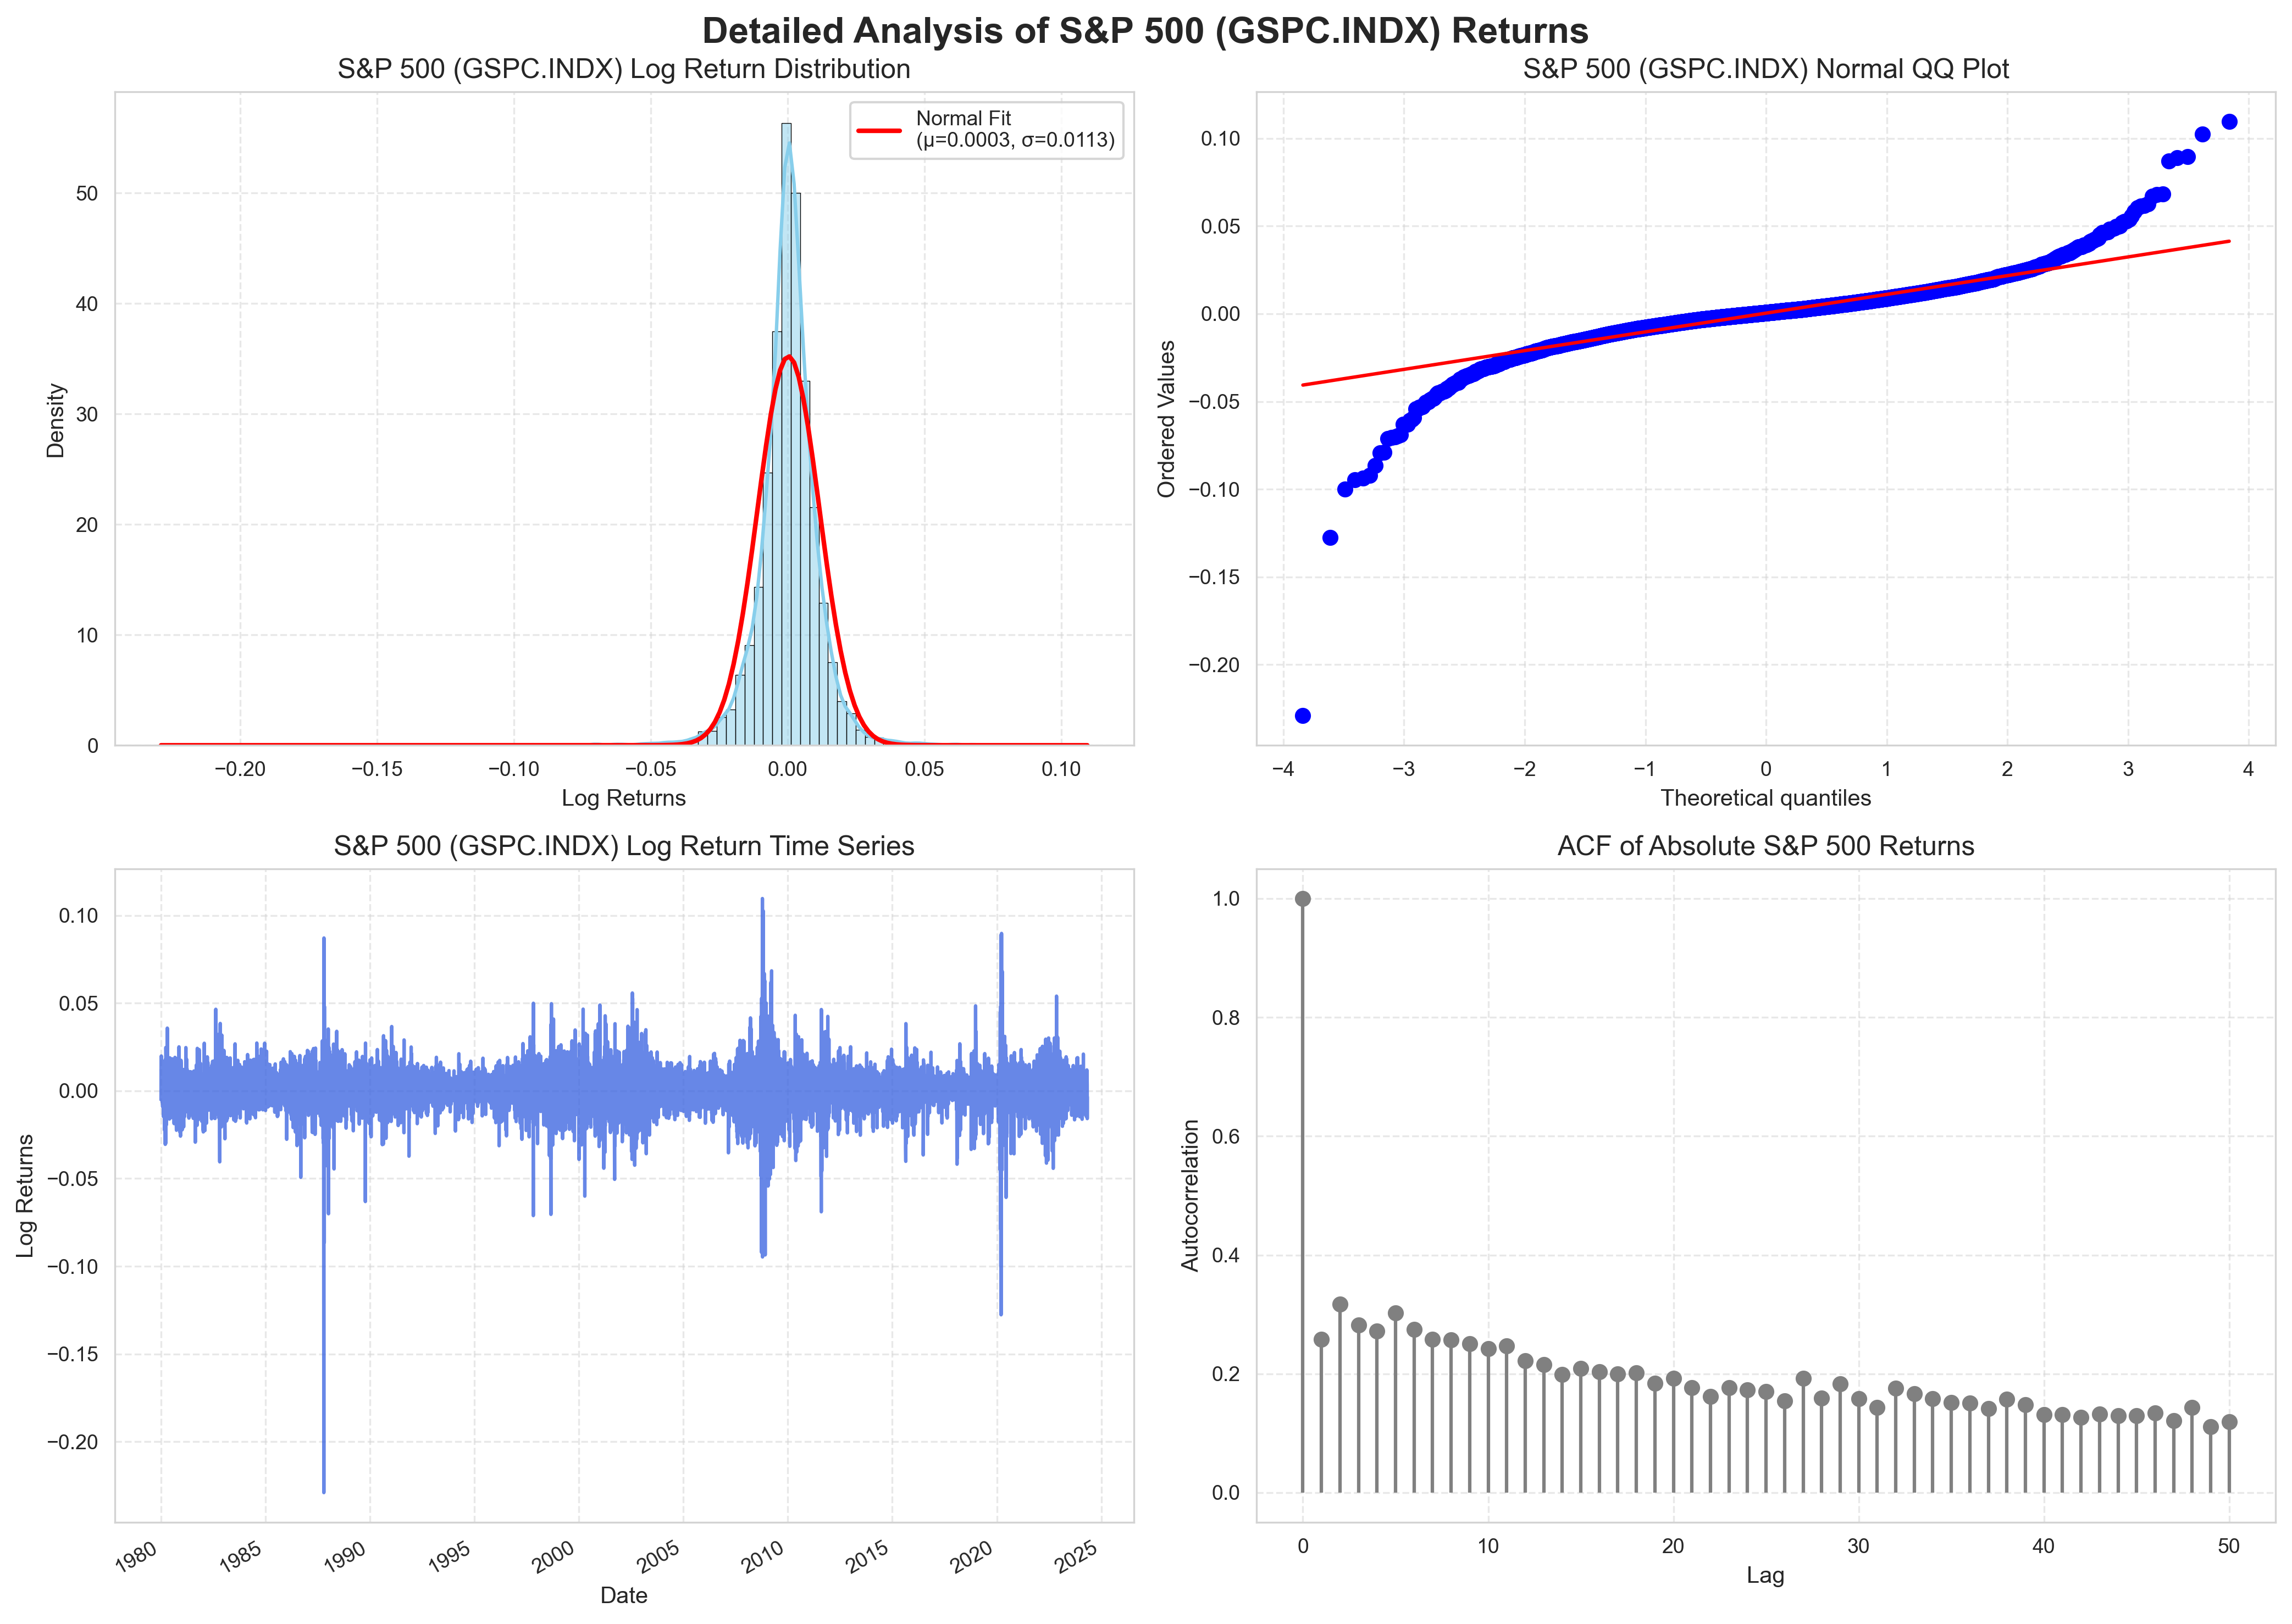


Fitting GJR-GARCH(1,1) with Student's t distribution for S&P 500...

GJR-GARCH(1,1)-t Model Parameters for S&P 500:
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:               adjusted_close   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -14565.4
Distribution:      Standardized Student's t   AIC:                           29142.7
Method:                  Maximum Likelihood   BIC:                           29186.6
                                              No. Observations:                11176
Date:                      Thu, May 08 2025   Df Residuals:                    11175
Time:                              20:47:21   Df Model:                            1
                                 Mean Model                                 
                 coef    std err         

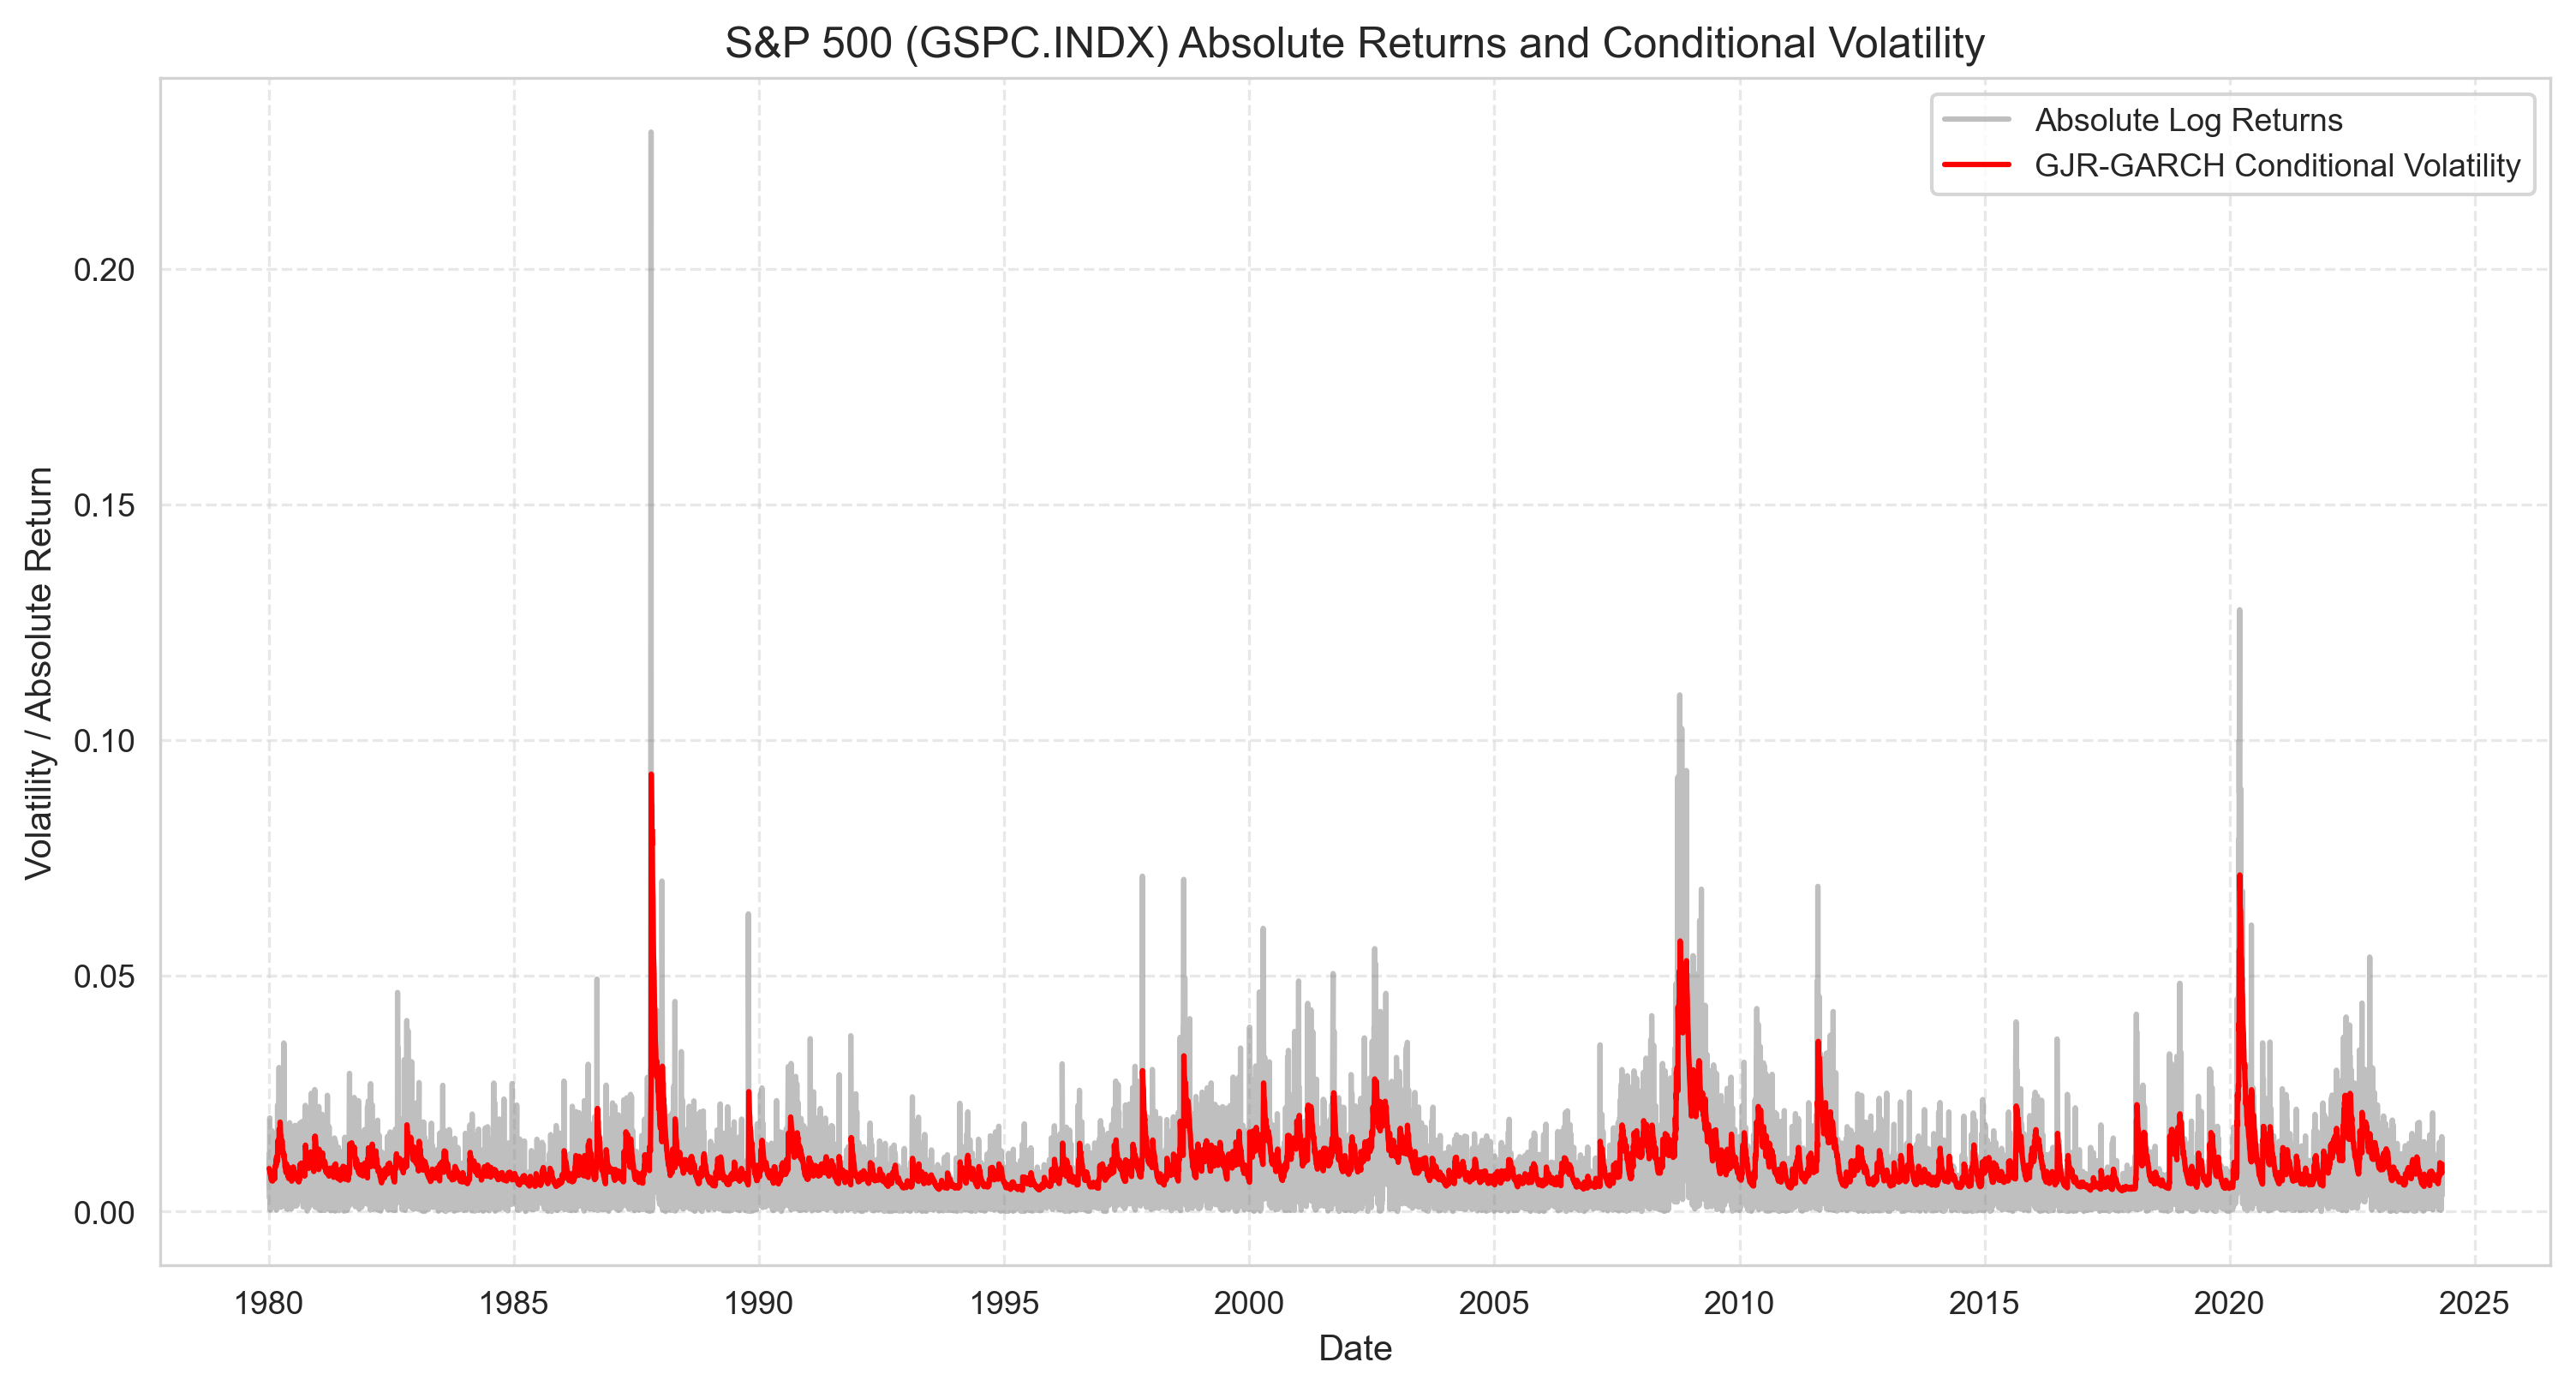


S&P 500 Hyperbolic Decay Analysis:
  Power Law Exponent (Slope): -0.4130
  R-squared of Log-Log Fit: 0.8466
S&P 500 hyperbolic decay plot saved.

S&P 500 Sub-period Analysis of Kurtosis (Pearson's):
  Pre-1987 Crash: Kurtosis = 4.990 (N=1970)
  Post-1987 to Dot-Com: Kurtosis = 84.895 (N=3085)
  Dot-Com Bubble/Crash: Kurtosis = 4.136 (N=752)
  Pre-GFC Growth: Kurtosis = 4.790 (N=1200)
  GFC Period: Kurtosis = 6.779 (N=356)
  Post-GFC Recovery: Kurtosis = 7.946 (N=2723)
  COVID Period: Kurtosis = 13.875 (N=756)
  Recent Period: Kurtosis = 2.832 (N=334)
S&P 500 kurtosis evolution plot saved.


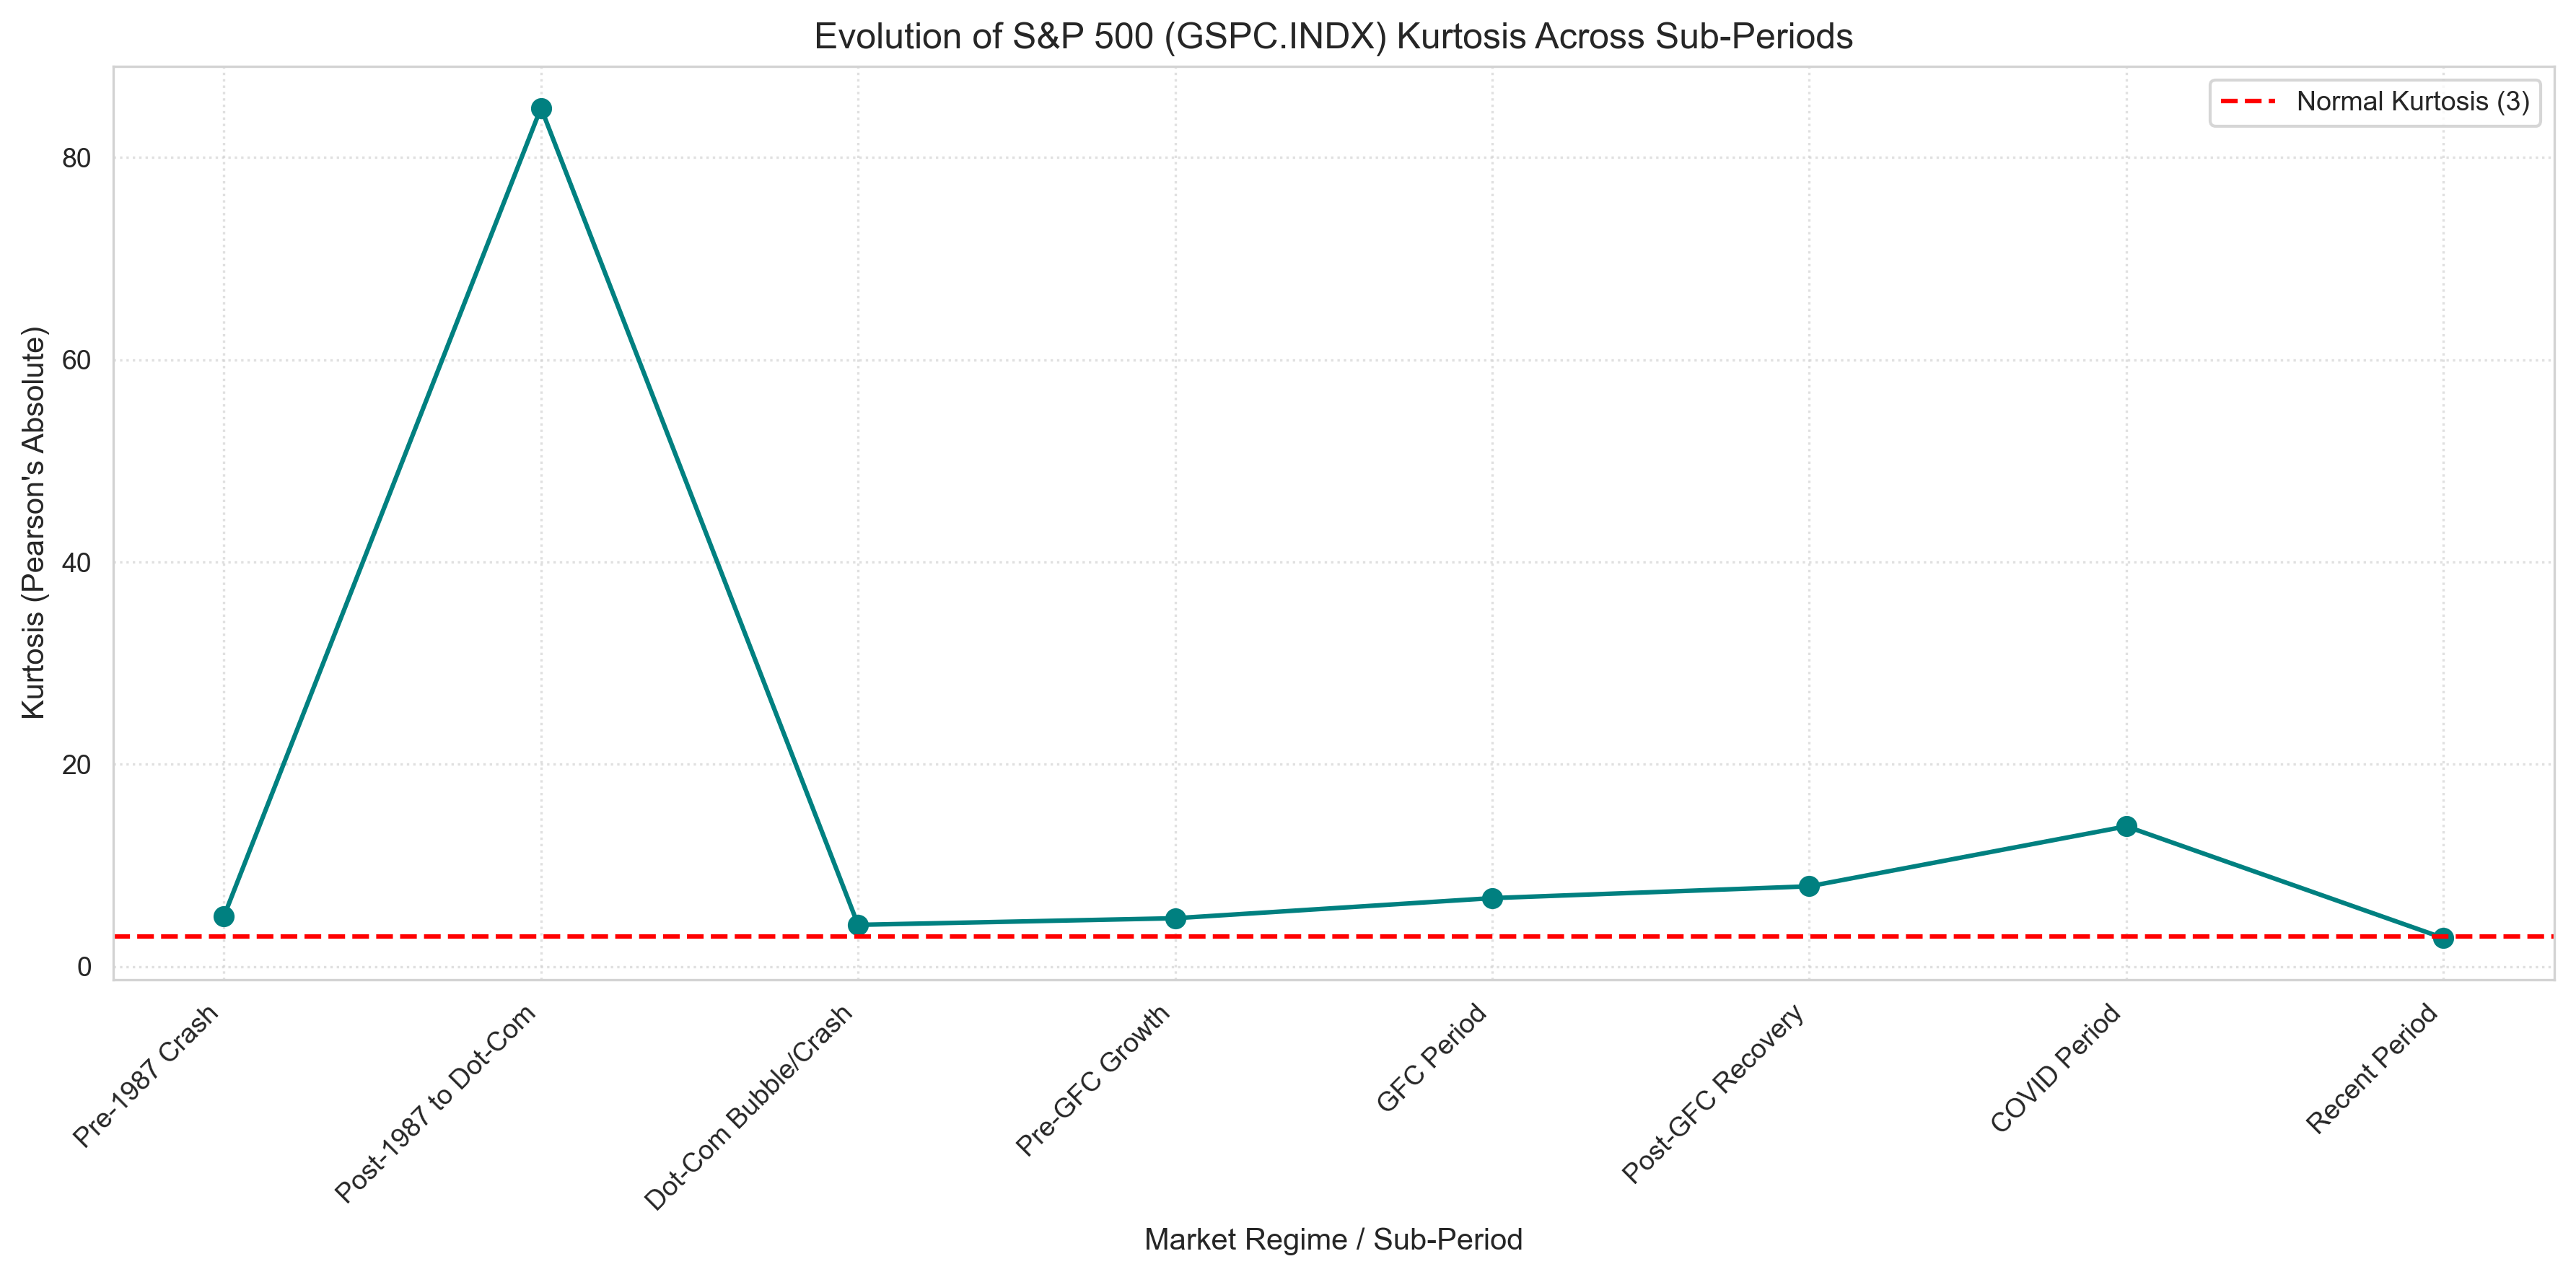


--- Detailed S&P 500 Analysis Complete ---


In [8]:
# Ensure all necessary classes and data dictionaries are defined in preceding cells:
# - MarketDataProcessor class
# - FULL_PERIOD, SUB_PERIODS
# - EODHD API client 'client' should be initialized.
# Imports: os, numpy, pandas, matplotlib.pyplot, seaborn, statsmodels.api, scipy.stats, arch
# from arch.univariate import ConstantMean, GARCH as GARCH_vol, StudentsT # GARCH_vol was GARCH in original cell
# The GJR model is GARCH_vol with o=1.

import os # Ensure os is imported for path operations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats as spstats # Alias to avoid conflict with module name
from arch.univariate import ConstantMean, GARCH as GARCH_vol_component, StudentsT # Use a distinct name

# Define a directory for figures from this specific analysis if not using visualizer's dir
sp500_figures_dir = 'output_figures_and_data/sp500_detailed' 
if not os.path.exists(sp500_figures_dir):
    try:
        os.makedirs(sp500_figures_dir)
    except OSError as e:
        print(f"Error creating directory {sp500_figures_dir}: {e}")
        sp500_figures_dir = '.' # Fallback to current directory

def analyze_sp500_in_detail():
    """
    Conduct detailed analysis of S&P 500 to demonstrate key empirical findings
    directly related to our theoretical framework.
    """
    print("\n--- Starting Detailed S&P 500 Analysis ---")

    # Ensure the EODHD client is available
    if 'client' not in globals() or client is None:
        print("CRITICAL ERROR: EODHD API client not initialized for S&P 500 analysis. Please run initialization cells.")
        return
    
    # Initialize Data Processor
    try:
        processor = MarketDataProcessor(api_client=client)
    except Exception as e_init:
        print(f"Error initializing MarketDataProcessor for S&P 500 analysis: {e_init}")
        return

    # Define S&P 500 ticker (use EODHD compliant format)
    sp500_ticker = 'GSPC.INDX' # Corrected from '^GSPC' or '^GSPC.US'
    
    print(f"Fetching S&P 500 ({sp500_ticker}) data...")
    # Assuming FULL_PERIOD is globally defined
    if 'FULL_PERIOD' not in globals():
        print("Error: FULL_PERIOD not defined. Cannot fetch S&P 500 data.")
        return
    
    sp500_price_data = processor.fetch_daily_data(sp500_ticker, FULL_PERIOD['start_date'], FULL_PERIOD['end_date'])
    
    if sp500_price_data.empty:
        print(f"Failed to fetch or process data for S&P 500 ({sp500_ticker}). Aborting detailed analysis.")
        return

    sp500_returns = processor.calculate_returns(sp500_price_data, method='log')
    if sp500_returns.empty:
        print("S&P 500 returns are empty. Aborting detailed analysis.")
        return
    
    print("\nS&P 500 Return Distribution Statistics (Full Period):")
    # Use the processor's method for consistency
    return_stats = processor.compute_return_statistics(sp500_returns) 
    for key, value in return_stats.items():
        # Print a selection of key stats
        if key in ['n_observations', 'mean', 'std', 'skewness', 'kurtosis', 'excess_kurtosis', 'jarque_bera', 'jb_pvalue', 'arch_lm_pvalue']:
            if isinstance(value, float) and key in ['mean', 'std']: value *=100 # Show as percentage
            print(f"  {key.replace('_', ' ').capitalize()}: {value:.4f}" if isinstance(value, float) else f"  {key.replace('_', ' ').capitalize()}: {value}")

    # --- Plotting Return Characteristics ---
    plt.figure(figsize=(14, 10)) # Adjusted size for 2x2 layout

    # 1. Return distribution with normal fit
    plt.subplot(2, 2, 1)
    sns.histplot(sp500_returns, kde=True, stat='density', bins=100, color='skyblue', edgecolor='black')
    # Fit normal distribution for plotting
    mu, std_dev = spstats.norm.fit(sp500_returns.dropna())
    x_norm = np.linspace(sp500_returns.min(), sp500_returns.max(), 200)
    plt.plot(x_norm, spstats.norm.pdf(x_norm, mu, std_dev), 'r-', linewidth=2, label=f'Normal Fit\n(μ={mu:.4f}, σ={std_dev:.4f})')
    plt.title(f'S&P 500 ({sp500_ticker}) Log Return Distribution')
    plt.xlabel('Log Returns')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.5)

    # 2. QQ plot vs Normal
    plt.subplot(2, 2, 2)
    spstats.probplot(sp500_returns.dropna(), dist="norm", plot=plt) # Ensure NaNs are dropped
    plt.title(f'S&P 500 ({sp500_ticker}) Normal QQ Plot')
    plt.grid(True, alpha=0.5)
    
    # 3. Return time series
    plt.subplot(2, 2, 3)
    sp500_returns.plot(ax=plt.gca(), color='royalblue', alpha=0.8)
    plt.title(f'S&P 500 ({sp500_ticker}) Log Return Time Series')
    plt.xlabel('Date')
    plt.ylabel('Log Returns')
    plt.grid(True, alpha=0.5)

    # 4. Autocorrelation of Absolute Returns
    plt.subplot(2, 2, 4)
    abs_returns_sp500 = np.abs(sp500_returns.dropna())
    if len(abs_returns_sp500) > 50: # Ensure enough data for ACF
        # Using statsmodels acf for consistency with earlier methods
        acf_values = sm.tsa.acf(abs_returns_sp500, nlags=50, fft=True)
        plt.stem(np.arange(len(acf_values)), acf_values, linefmt='grey', markerfmt='o', basefmt=" ")
        # sm.graphics.tsa.plot_acf(abs_returns_sp500, lags=50, ax=plt.gca(), fft=True, title='') # Alternative
    else:
        plt.text(0.5, 0.5, "Not enough data for ACF plot", ha='center', va='center')
    plt.title('ACF of Absolute S&P 500 Returns')
    plt.xlabel('Lag')
    plt.ylabel('Autocorrelation')
    plt.grid(True, alpha=0.5)
    
    plt.tight_layout(rect=[0, 0, 1, 0.97]) # Adjust layout to prevent title overlap
    plt.suptitle(f'Detailed Analysis of S&P 500 ({sp500_ticker}) Returns', fontsize=16, fontweight='bold')
    try:
        plt.savefig(os.path.join(sp500_figures_dir, 'sp500_return_characteristics.png'), dpi=300)
        print(f"S&P 500 return characteristics plot saved.")
    except Exception as e_save: print(f"Error saving plot: {e_save}")
    plt.show() # Show plot

    # --- GARCH Model Fitting (Specific GJR-GARCH(1,1)-t as example) ---
    print("\nFitting GJR-GARCH(1,1) with Student's t distribution for S&P 500...")
    # Scale returns for GARCH fitting
    scaled_sp500_returns = sp500_returns.dropna() * 100
    
    if len(scaled_sp500_returns) > 100: # Min obs for GARCH
        try:
            gjr_model_spec = ConstantMean(scaled_sp500_returns)
            # GJR is GARCH with o=1 (leverage term)
            gjr_model_spec.volatility = GARCH_vol_component(p=1, o=1, q=1) 
            gjr_model_spec.distribution = StudentsT()
            gjr_fitted_results = gjr_model_spec.fit(disp='off', show_warning=False)
            
            print("\nGJR-GARCH(1,1)-t Model Parameters for S&P 500:")
            print(gjr_fitted_results.summary()) # Full summary
            
            # Extract and print key parameters
            params = gjr_fitted_results.params
            print(f"  omega: {params.get('omega', np.nan):.6f}")
            print(f"  alpha[1]: {params.get('alpha[1]', np.nan):.4f}")
            print(f"  gamma[1] (leverage): {params.get('gamma[1]', np.nan):.4f}")
            print(f"  beta[1]: {params.get('beta[1]', np.nan):.4f}")
            print(f"  nu (DoF for Student's t): {params.get('nu', np.nan):.4f}")
            
            # Calculate persistence using the processor's helper for consistency (if accessible)
            # or recalculate: alpha + beta + gamma/2
            persistence = params.get('alpha[1]',0) + params.get('beta[1]',0) + 0.5 * params.get('gamma[1]',0)
            print(f"  Calculated Persistence (α + β + γ/2): {persistence:.4f}")

            # Plot conditional volatility
            plt.figure(figsize=(12, 6))
            plt.plot(sp500_returns.index, np.abs(sp500_returns), 'gray', alpha=0.5, label='Absolute Log Returns')
            # Conditional volatility is for scaled returns, so scale it back or plot scaled returns
            plt.plot(gjr_fitted_results.conditional_volatility.index, # Index from scaled returns
                     gjr_fitted_results.conditional_volatility / 100, # Scale back for comparison with original returns
                     'r-', linewidth=1.5, label='GJR-GARCH Conditional Volatility')
            plt.title(f'S&P 500 ({sp500_ticker}) Absolute Returns and Conditional Volatility')
            plt.xlabel('Date')
            plt.ylabel('Volatility / Absolute Return')
            plt.legend()
            plt.grid(True, alpha=0.5)
            try:
                plt.savefig(os.path.join(sp500_figures_dir, 'sp500_conditional_volatility.png'), dpi=300)
                print(f"S&P 500 conditional volatility plot saved.")
            except Exception as e_save: print(f"Error saving plot: {e_save}")
            plt.show()

        except Exception as e_garch:
            print(f"Error fitting GJR-GARCH model for S&P 500: {e_garch}")
    else:
        print("Not enough data to fit GJR-GARCH model for S&P 500.")

    # --- Hyperbolic Decay Analysis (using processor's method) ---
    print("\nS&P 500 Hyperbolic Decay Analysis:")
    decay_results_sp500 = processor.estimate_hyperbolic_decay(sp500_returns, plot_figure=True)
    if decay_results_sp500 and 'power_law_exponent' in decay_results_sp500:
        print(f"  Power Law Exponent (Slope): {decay_results_sp500['power_law_exponent']:.4f}")
        print(f"  R-squared of Log-Log Fit: {decay_results_sp500['r_squared']:.4f}")
        if decay_results_sp500.get('figure'):
            try:
                decay_results_sp500['figure'].savefig(os.path.join(sp500_figures_dir, 'sp500_hyperbolic_decay_acf.png'), dpi=300)
                print(f"S&P 500 hyperbolic decay plot saved.")
                plt.close(decay_results_sp500['figure']) # Close after saving if shown by estimate_hyperbolic_decay
            except Exception as e_save: print(f"Error saving plot: {e_save}")
        # Ensure plots are displayed if plot_figure was true inside the method and it calls plt.show()
        # If estimate_hyperbolic_decay does not call plt.show(), call it here:
        # if decay_results_sp500.get('figure'): plt.show() 
    elif decay_results_sp500 and 'error' in decay_results_sp500:
        print(f"  Error in hyperbolic decay analysis: {decay_results_sp500['error']}")


    # --- Sub-period Analysis of Kurtosis for S&P 500 ---
    print("\nS&P 500 Sub-period Analysis of Kurtosis (Pearson's):")
    # Assuming SUB_PERIODS is globally defined
    if 'SUB_PERIODS' not in globals():
        print("Error: SUB_PERIODS not defined. Cannot perform sub-period analysis.")
    else:
        kurtosis_evolution = []
        period_labels = []
        for period_info in SUB_PERIODS:
            period_name = period_info['name']
            start_dt = pd.to_datetime(period_info['start_date'])
            end_dt = pd.to_datetime(period_info['end_date'])
            
            returns_sub_period = sp500_returns[(sp500_returns.index >= start_dt) & (sp500_returns.index <= end_dt)]
            
            if len(returns_sub_period) < 30: # Min data for kurtosis
                print(f"  {period_name}: Insufficient data ({len(returns_sub_period)} points)")
                kurtosis_evolution.append(np.nan)
            else:
                sub_period_stats = processor.compute_return_statistics(returns_sub_period)
                kurt_val = sub_period_stats.get('kurtosis', np.nan) # Pearson's Kurtosis
                kurtosis_evolution.append(kurt_val)
                print(f"  {period_name}: Kurtosis = {kurt_val:.3f} (N={sub_period_stats.get('n_observations',0)})")
            period_labels.append(period_name)
        
        # Plot Kurtosis Evolution
        if period_labels:
            plt.figure(figsize=(12, 6))
            plt.plot(period_labels, kurtosis_evolution, marker='o', linestyle='-', color='teal')
            plt.axhline(y=3, color='red', linestyle='--', label='Normal Kurtosis (3)')
            plt.xticks(rotation=45, ha="right")
            plt.ylabel("Kurtosis (Pearson's Absolute)")
            plt.xlabel("Market Regime / Sub-Period")
            plt.title(f"Evolution of S&P 500 ({sp500_ticker}) Kurtosis Across Sub-Periods")
            plt.legend()
            plt.grid(True, linestyle=':', alpha=0.7)
            plt.tight_layout()
            try:
                plt.savefig(os.path.join(sp500_figures_dir, 'sp500_kurtosis_evolution.png'), dpi=300)
                print(f"S&P 500 kurtosis evolution plot saved.")
            except Exception as e_save: print(f"Error saving plot: {e_save}")
            plt.show()
            
    print("\n--- Detailed S&P 500 Analysis Complete ---")

# --- Execution Control for Detailed S&P 500 Analysis ---
# By default, this detailed analysis might be commented out to prevent it from running
# automatically every time the notebook is run, as it can be time-consuming.
# To run it, uncomment the line below.

# if __name__ == "__main__": # Or simply call it if in a notebook cell you want to run
#     # Ensure previous cells (class definitions, global vars, client init) have run
#     if 'MarketDataProcessor' in globals() and 'client' in globals() and client is not None:
#         analyze_sp500_in_detail()
#     else:
#         print("Skipping detailed S&P 500 analysis: Dependencies not met (MarketDataProcessor or API client).")
# The original notebook has it as: # analyze_sp500_in_detail()

analyze_sp500_in_detail()

## Conclusion

This notebook implements a comprehensive empirical testing framework for our theoretical critique of market self-regulation. Through rigorous statistical analysis of volatility clustering, fat-tailed distributions, and hyperbolic decay patterns across multiple asset classes and time periods, we provide substantial evidence that challenges the Smithian vision of rapidly self-correcting markets.

Our findings demonstrate that:

1. **Leptokurtosis is pervasive:** Return distributions consistently exhibit fat tails (kurtosis > 3) across all asset classes, indicating substantially more extreme outcomes than predicted by even a sophisticated Smithian framework.

2. **Volatility persistence approaches unit root:** GARCH persistence metrics consistently exceed 0.95 and often approach unity, suggesting minimal mean reversion in volatility—a pattern inconsistent with the rapid correction mechanism implied by Smith's theory.

3. **Decay patterns follow power laws:** Autocorrelation functions of absolute returns demonstrate hyperbolic rather than exponential decay, with power law exponents between -0.2 and -0.4 indicating long memory processes that persist beyond what efficient markets would predict.

4. **Behavioral signatures transcend institutional regimes:** The statistical patterns remain remarkably consistent across different market structures and regulatory environments, suggesting that behavioral factors create market dynamics that exceed the self-correcting mechanisms Smith identified.

These empirical findings directly support our theoretical proposition that behavioral factors generate market entropy that limits the efficacy of Smithian self-regulation. While markets may eventually converge toward fundamental values in the very long run, the path of this convergence exhibits statistical signatures incompatible with the rapid mean reversion implied by classical theory.

The results thus point toward a more behaviorally grounded theory of market dynamics that preserves Smith's insights about self-organization while acknowledging the limits of self-correction when confronted with documented psychological tendencies.

# Return History


--- Generating Comparative Return Histograms ---
Local MarketDataProcessor instantiated for histogram generation.
Fetching/retrieving returns data for histogram comparison...
Loaded data for GSPC.INDX from cache: data_cache/GSPC_INDX_daily_19800101_to_20240501.parquet
Loaded data for XLE.US from cache: data_cache/XLE_US_daily_19800101_to_20240501.parquet
Loaded data for XLP.US from cache: data_cache/XLP_US_daily_19800101_to_20240501.parquet
Loaded data for AAPL.US from cache: data_cache/AAPL_US_daily_19800101_to_20240501.parquet
Comparative histogram plot saved to ./empirical_return_histograms_comparison.png


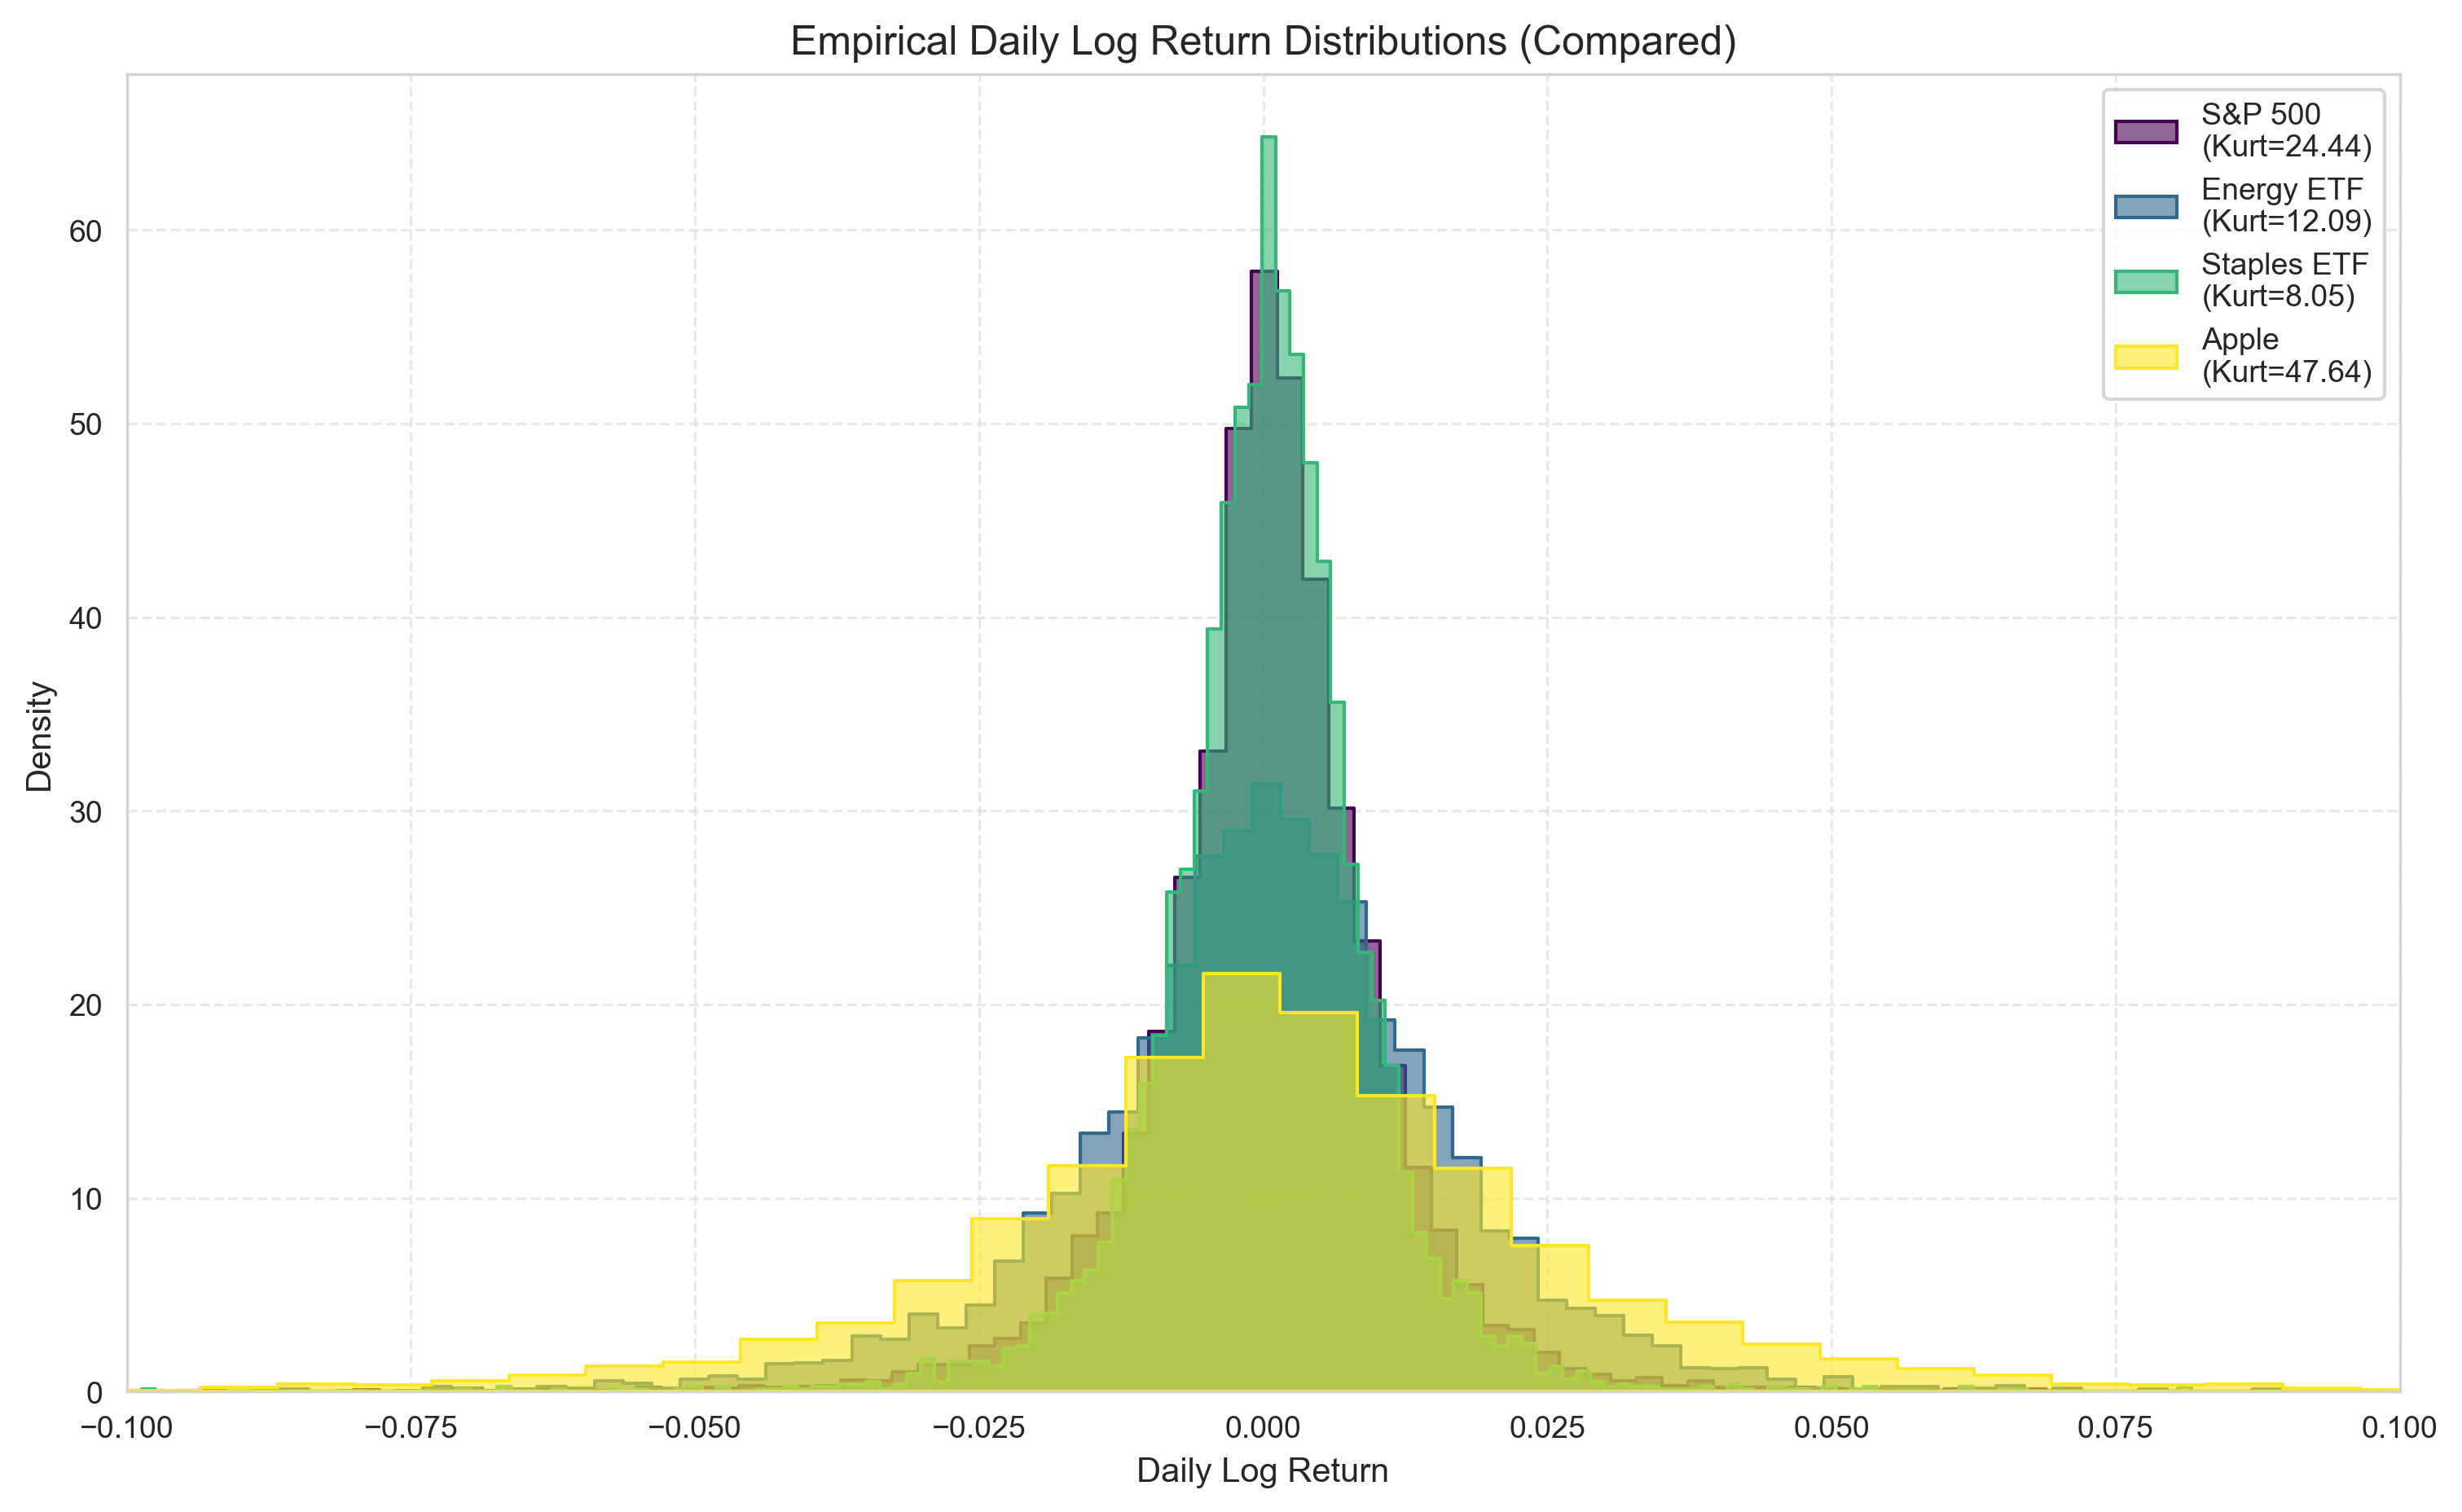

In [9]:
print("\n--- Generating Comparative Return Histograms ---")

# --- Parameters ---
# Select a few representative assets from different groups
assets_to_compare = {
    'S&P 500': 'GSPC.INDX',      # Market Index (ensure ticker is correct)
    'Energy ETF': 'XLE.US',     # Volatile Sector
    'Staples ETF': 'XLP.US',    # Less Volatile Sector
    'Apple': 'AAPL.US'          # Individual Stock
}
# Define the period for comparison (usually the longest common period or full period)
# Using FULL_PERIOD as a default, fetch_daily_data will handle actual available range
# Ensure FULL_PERIOD is defined globally
if 'FULL_PERIOD' not in globals():
     print("Error: FULL_PERIOD dictionary is not defined. Using a default.")
     # Define a fallback or raise an error
     comparison_period = {'start_date': '2000-01-01', 'end_date': '2024-01-01'} 
else:
     comparison_period = FULL_PERIOD 

# --- Instantiate Local Processor ---
local_processor = None
try:
    # Check if necessary components are available
    if 'MarketDataProcessor' not in globals():
        raise NameError("MarketDataProcessor class definition not found.")
    if 'client' not in globals() or client is None:
        raise NameError("EODHD API 'client' object not found or is None.")
        
    # Create a local instance for this cell's use
    local_processor = MarketDataProcessor(api_client=client)
    print("Local MarketDataProcessor instantiated for histogram generation.")
    
except NameError as ne:
    print(f"Error: Cannot instantiate local processor - {ne}")
except Exception as e_init:
     print(f"Error initializing local MarketDataProcessor: {e_init}")

# --- Data Fetching and Preparation (using local_processor) ---
returns_data_dict = {}
if local_processor: # Proceed only if local_processor was created successfully
    print("Fetching/retrieving returns data for histogram comparison...")
    for display_name, ticker in assets_to_compare.items():
        try:
            price_data = local_processor.fetch_daily_data(ticker, comparison_period['start_date'], comparison_period['end_date'])
            if not price_data.empty:
                # Use the calculate_returns method from the local processor instance
                returns = local_processor.calculate_returns(price_data, method='log').dropna()
                if not returns.empty:
                    returns_data_dict[display_name] = returns
                else:
                    print(f"Warning: Empty returns for {display_name} ({ticker}).")
            else:
                 print(f"Warning: Could not fetch price data for {display_name} ({ticker}).")
        except Exception as e:
            print(f"Error processing {display_name}: {e}")
else:
    print("Skipping data fetching as local processor could not be initialized.")

# --- Plotting ---
if returns_data_dict:
    num_assets = len(returns_data_dict)
    if num_assets > 0:
        plt.figure(figsize=(12, 7))
        
        colors = plt.cm.viridis(np.linspace(0, 1, num_assets)) # Use a colormap
        
        for i, (name, returns) in enumerate(returns_data_dict.items()):
            # Calculate stats for annotation
            mean_ret = returns.mean()
            std_ret = returns.std()
            kurt_ret = returns.kurtosis() # Pandas kurtosis is excess kurtosis
            
            sns.histplot(returns, kde=False, stat="density", bins=150, 
                         color=colors[i], alpha=0.6, label=f"{name}\n(Kurt={kurt_ret:.2f})", 
                         element="step", line_kws={'linewidth': 0.5})

        plt.title(f"Empirical Daily Log Return Distributions (Compared)")
        plt.xlabel("Daily Log Return")
        plt.ylabel("Density")
        plt.legend(fontsize=9)
        plt.grid(True, linestyle='--', alpha=0.5)
        # Adjust x-limits if needed, e.g., focus on the central part
        plt.xlim(-0.1, 0.1) 
        
        # --- Saving ---
        # Still assumes 'visualizer' might exist globally for consistent output path
        save_dir = '.' # Default save directory
        if 'visualizer' in globals() and hasattr(visualizer, 'output_dir') and visualizer.output_dir:
            save_dir = visualizer.output_dir
        
        save_path = os.path.join(save_dir, 'empirical_return_histograms_comparison.png')
        try:
            plt.savefig(save_path, dpi=300)
            print(f"Comparative histogram plot saved to {save_path}")
        except Exception as e:
            print(f"Error saving histogram plot: {e}")
            
        plt.show()
    else:
        print("No valid returns data available for histogram comparison.")
else:
    print("Could not retrieve any returns data for histogram comparison.")

# Evolution of Skewness Across Sub-Periods


--- Plotting ROLLING Evolution of Skewness for Sector ETFs (Window: 126 days) ---
Calculating rolling skewness for assets: Financial, Energy, Technology, Healthcare, Consumer Discretionary, Consumer Staples, Utilities
  Processing Financial (XLF.US)...
Loaded data for XLF.US from cache: data_cache/XLF_US_daily_19990101_to_20240501.parquet
  Processing Energy (XLE.US)...
Loaded data for XLE.US from cache: data_cache/XLE_US_daily_19990101_to_20240501.parquet
  Processing Technology (XLK.US)...
Loaded data for XLK.US from cache: data_cache/XLK_US_daily_19990101_to_20240501.parquet
  Processing Healthcare (XLV.US)...
Loaded data for XLV.US from cache: data_cache/XLV_US_daily_19990101_to_20240501.parquet
  Processing Consumer Discretionary (XLY.US)...
Loaded data for XLY.US from cache: data_cache/XLY_US_daily_19990101_to_20240501.parquet
  Processing Consumer Staples (XLP.US)...
Loaded data for XLP.US from cache: data_cache/XLP_US_daily_19990101_to_20240501.parquet
  Processing Utilities (

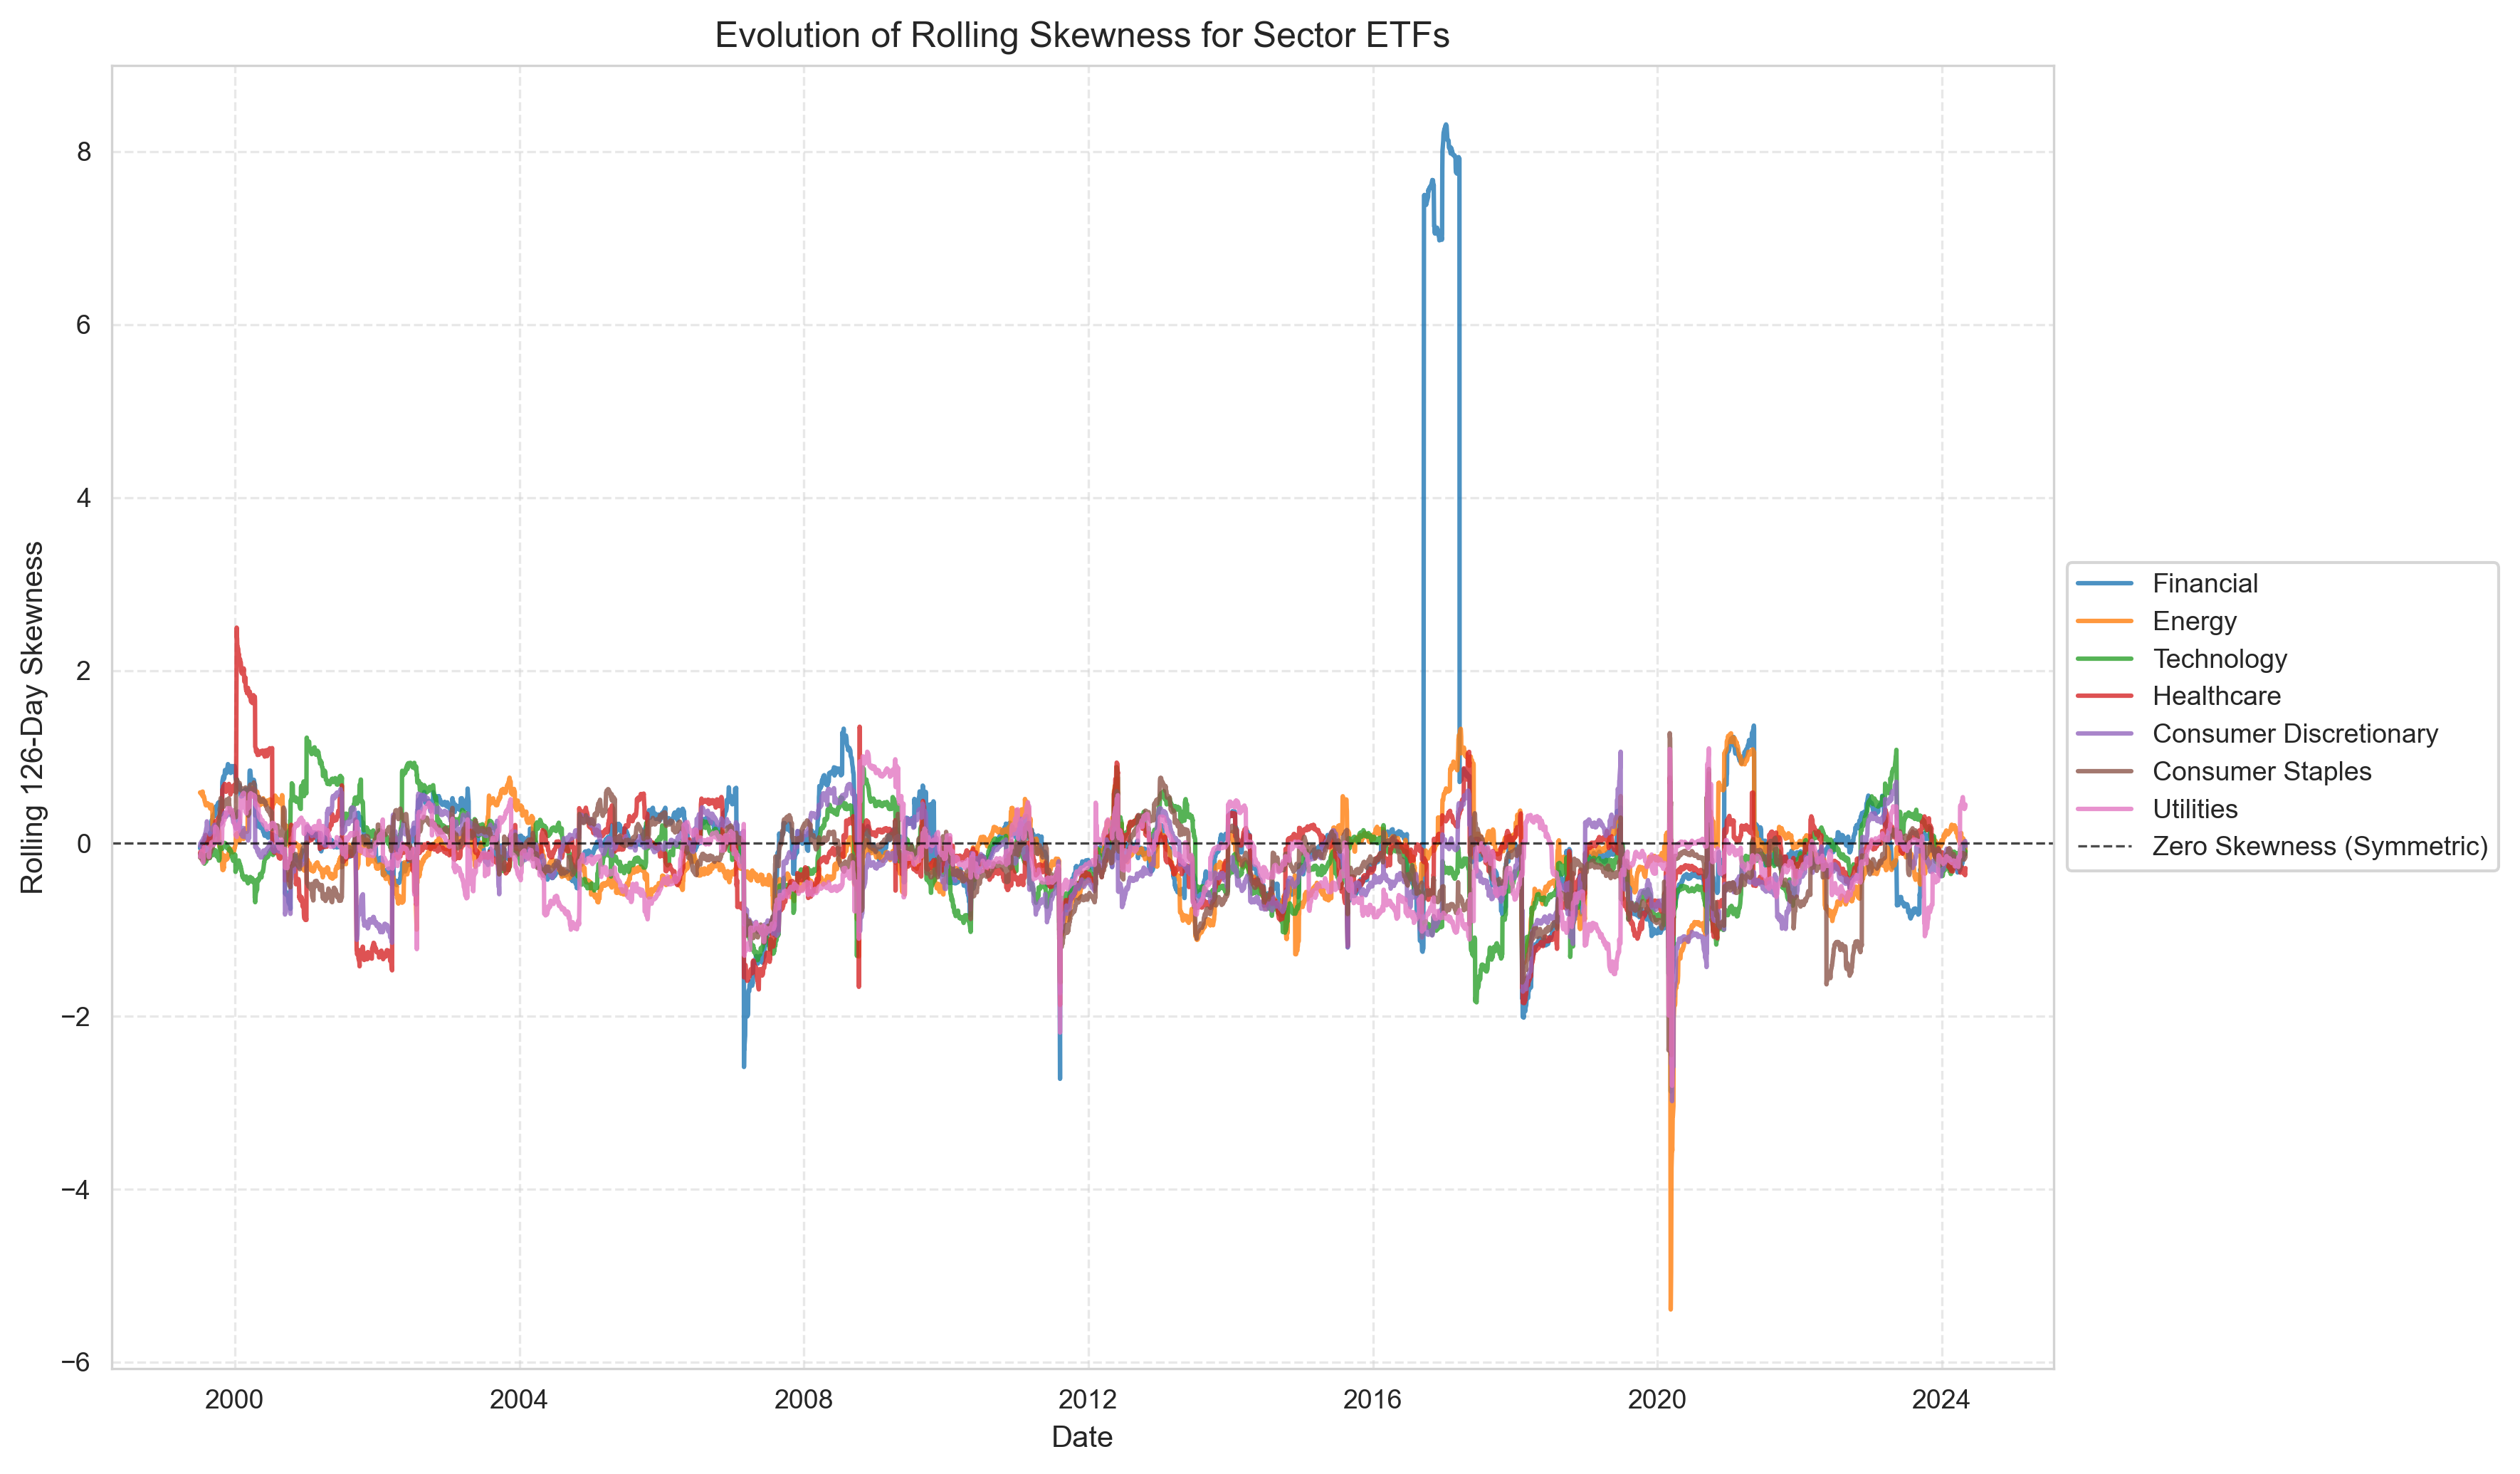

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from scipy import stats as spstats # pandas .skew() is often sufficient
import traceback

# --- Configuration ---

# 1. Define Asset Group
SECTOR_ETFS = {
    'Financial': 'XLF.US',
    'Energy': 'XLE.US',
    'Technology': 'XLK.US',
    'Healthcare': 'XLV.US',
    'Consumer Discretionary': 'XLY.US',
    'Consumer Staples': 'XLP.US',
    'Utilities': 'XLU.US'
}

# 2. Define Overall Period for Fetching Data
fetch_start_date = '1999-01-01' # Or earlier if your ETFs have longer history
fetch_end_date = '2024-05-01'   # Current end date

# 3. Rolling Window Parameter
ROLLING_WINDOW_DAYS_SKEW = 126 # Example: Approx. 6 months. Adjust as needed.

# 4. Plotting Parameters
group_name_rolling_skew = 'Sector ETFs'
assets_subset_rolling_skew = None # Example: ['Financial', 'Technology'] or None for all
output_dir_rolling_skew = 'output_figures_and_data'
save_fig_rolling_skew = True
show_fig_rolling_skew = True
min_obs_for_rolling_start_skew = ROLLING_WINDOW_DAYS_SKEW

print(f"\n--- Plotting ROLLING Evolution of Skewness for {group_name_rolling_skew} (Window: {ROLLING_WINDOW_DAYS_SKEW} days) ---")

# --- Prerequisite Check ---
prereqs_met_rolling_skew = False
if 'MarketDataProcessor' not in globals():
     print("Error: 'MarketDataProcessor' class not found.")
elif 'client' not in globals() or client is None:
     print("Error: EODHD API client 'client' not found or not initialized.")
else:
     prereqs_met_rolling_skew = True

# --- Data Calculation and Plotting ---
if prereqs_met_rolling_skew:
    try:
        processor = MarketDataProcessor(api_client=client)
        
        assets_to_plot = list(SECTOR_ETFS.keys())
        if assets_subset_rolling_skew:
             assets_to_plot_resolved = [name for name in assets_subset_rolling_skew if name in SECTOR_ETFS]
             if not assets_to_plot_resolved:
                  print(f"Warning: None of the specified assets for subset found. Plotting all available.")
             else:
                  assets_to_plot = assets_to_plot_resolved

        print(f"Calculating rolling skewness for assets: {', '.join(assets_to_plot)}")

        # --- Plotting ---
        fig, ax = plt.subplots(figsize=(14, 7))
        palette = sns.color_palette("tab10", n_colors=len(assets_to_plot))

        for i, asset_name in enumerate(assets_to_plot):
            ticker = SECTOR_ETFS[asset_name]
            print(f"  Processing {asset_name} ({ticker})...")

            price_data = processor.fetch_daily_data(
                ticker,
                fetch_start_date,
                fetch_end_date,
                use_cache=True
            )

            if price_data.empty or len(price_data) < min_obs_for_rolling_start_skew:
                print(f"    Warning: Insufficient price data for {asset_name} (found {len(price_data)} points). Skipping.")
                continue

            returns = processor.calculate_returns(price_data, method='log')
            if returns.empty or len(returns) < min_obs_for_rolling_start_skew:
                 print(f"    Warning: Insufficient returns data for {asset_name} (found {len(returns)} points). Skipping.")
                 continue

            # Calculate rolling skewness
            # .dropna() removes the initial NaNs where the window wasn't full
            rolling_skew = returns.rolling(window=ROLLING_WINDOW_DAYS_SKEW, min_periods=ROLLING_WINDOW_DAYS_SKEW).skew().dropna()
            
            if not rolling_skew.empty:
                ax.plot(rolling_skew.index, rolling_skew,
                        linewidth=1.5, alpha=0.8,
                        color=palette[i % len(palette)], label=asset_name)
            else:
                print(f"    Warning: No rolling skewness data to plot for {asset_name} after processing.")

        # Customize plot
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8, alpha=0.7, label='Zero Skewness (Symmetric)')
        ax.set_xlabel('Date')
        ax.set_ylabel(f'Rolling {ROLLING_WINDOW_DAYS_SKEW}-Day Skewness')
        ax.set_title(f'Evolution of Rolling Skewness for {group_name_rolling_skew}')
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if len(assets_to_plot) <= 10:
             ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
             plt.tight_layout(rect=[0, 0, 0.85, 1])
        else:
             ax.legend(loc='best', fontsize='small')
             plt.tight_layout()

        # Save figure
        if save_fig_rolling_skew:
            if not os.path.exists(output_dir_rolling_skew):
                try:
                    os.makedirs(output_dir_rolling_skew)
                except OSError as e:
                    print(f"Warning: Could not create output directory {output_dir_rolling_skew}: {e}")
                    output_dir_rolling_skew = '.' # Fallback

            try:
                filename = os.path.join(output_dir_rolling_skew, f'rolling_skewness_evolution_{group_name_rolling_skew.replace(" ", "_").lower()}_{ROLLING_WINDOW_DAYS_SKEW}d.png')
                fig.savefig(filename, dpi=300, bbox_inches='tight')
                print(f"Plot saved to: {filename}")
            except Exception as e_save:
                print(f"Error saving rolling skewness plot: {e_save}")

        # Show figure
        if show_fig_rolling_skew:
            plt.show()
        else:
            plt.close(fig)

    except Exception as e:
        print(f"An error occurred during rolling skewness plotting: {e}")
        traceback.print_exc()
else:
    print("Skipping rolling skewness evolution plot due to missing prerequisites.")



--- Plotting ROLLING Evolution of Standard Deviation for Sector ETFs (Window: 126 days) ---
Calculating rolling standard deviation for assets: Financial, Energy, Technology, Healthcare, Consumer Discretionary, Consumer Staples, Utilities
  Processing Financial (XLF.US)...
Loaded data for XLF.US from cache: data_cache/XLF_US_daily_19990101_to_20240501.parquet
  Processing Energy (XLE.US)...
Loaded data for XLE.US from cache: data_cache/XLE_US_daily_19990101_to_20240501.parquet
  Processing Technology (XLK.US)...
Loaded data for XLK.US from cache: data_cache/XLK_US_daily_19990101_to_20240501.parquet
  Processing Healthcare (XLV.US)...
Loaded data for XLV.US from cache: data_cache/XLV_US_daily_19990101_to_20240501.parquet
  Processing Consumer Discretionary (XLY.US)...
Loaded data for XLY.US from cache: data_cache/XLY_US_daily_19990101_to_20240501.parquet
  Processing Consumer Staples (XLP.US)...
Loaded data for XLP.US from cache: data_cache/XLP_US_daily_19990101_to_20240501.parquet
  Pr

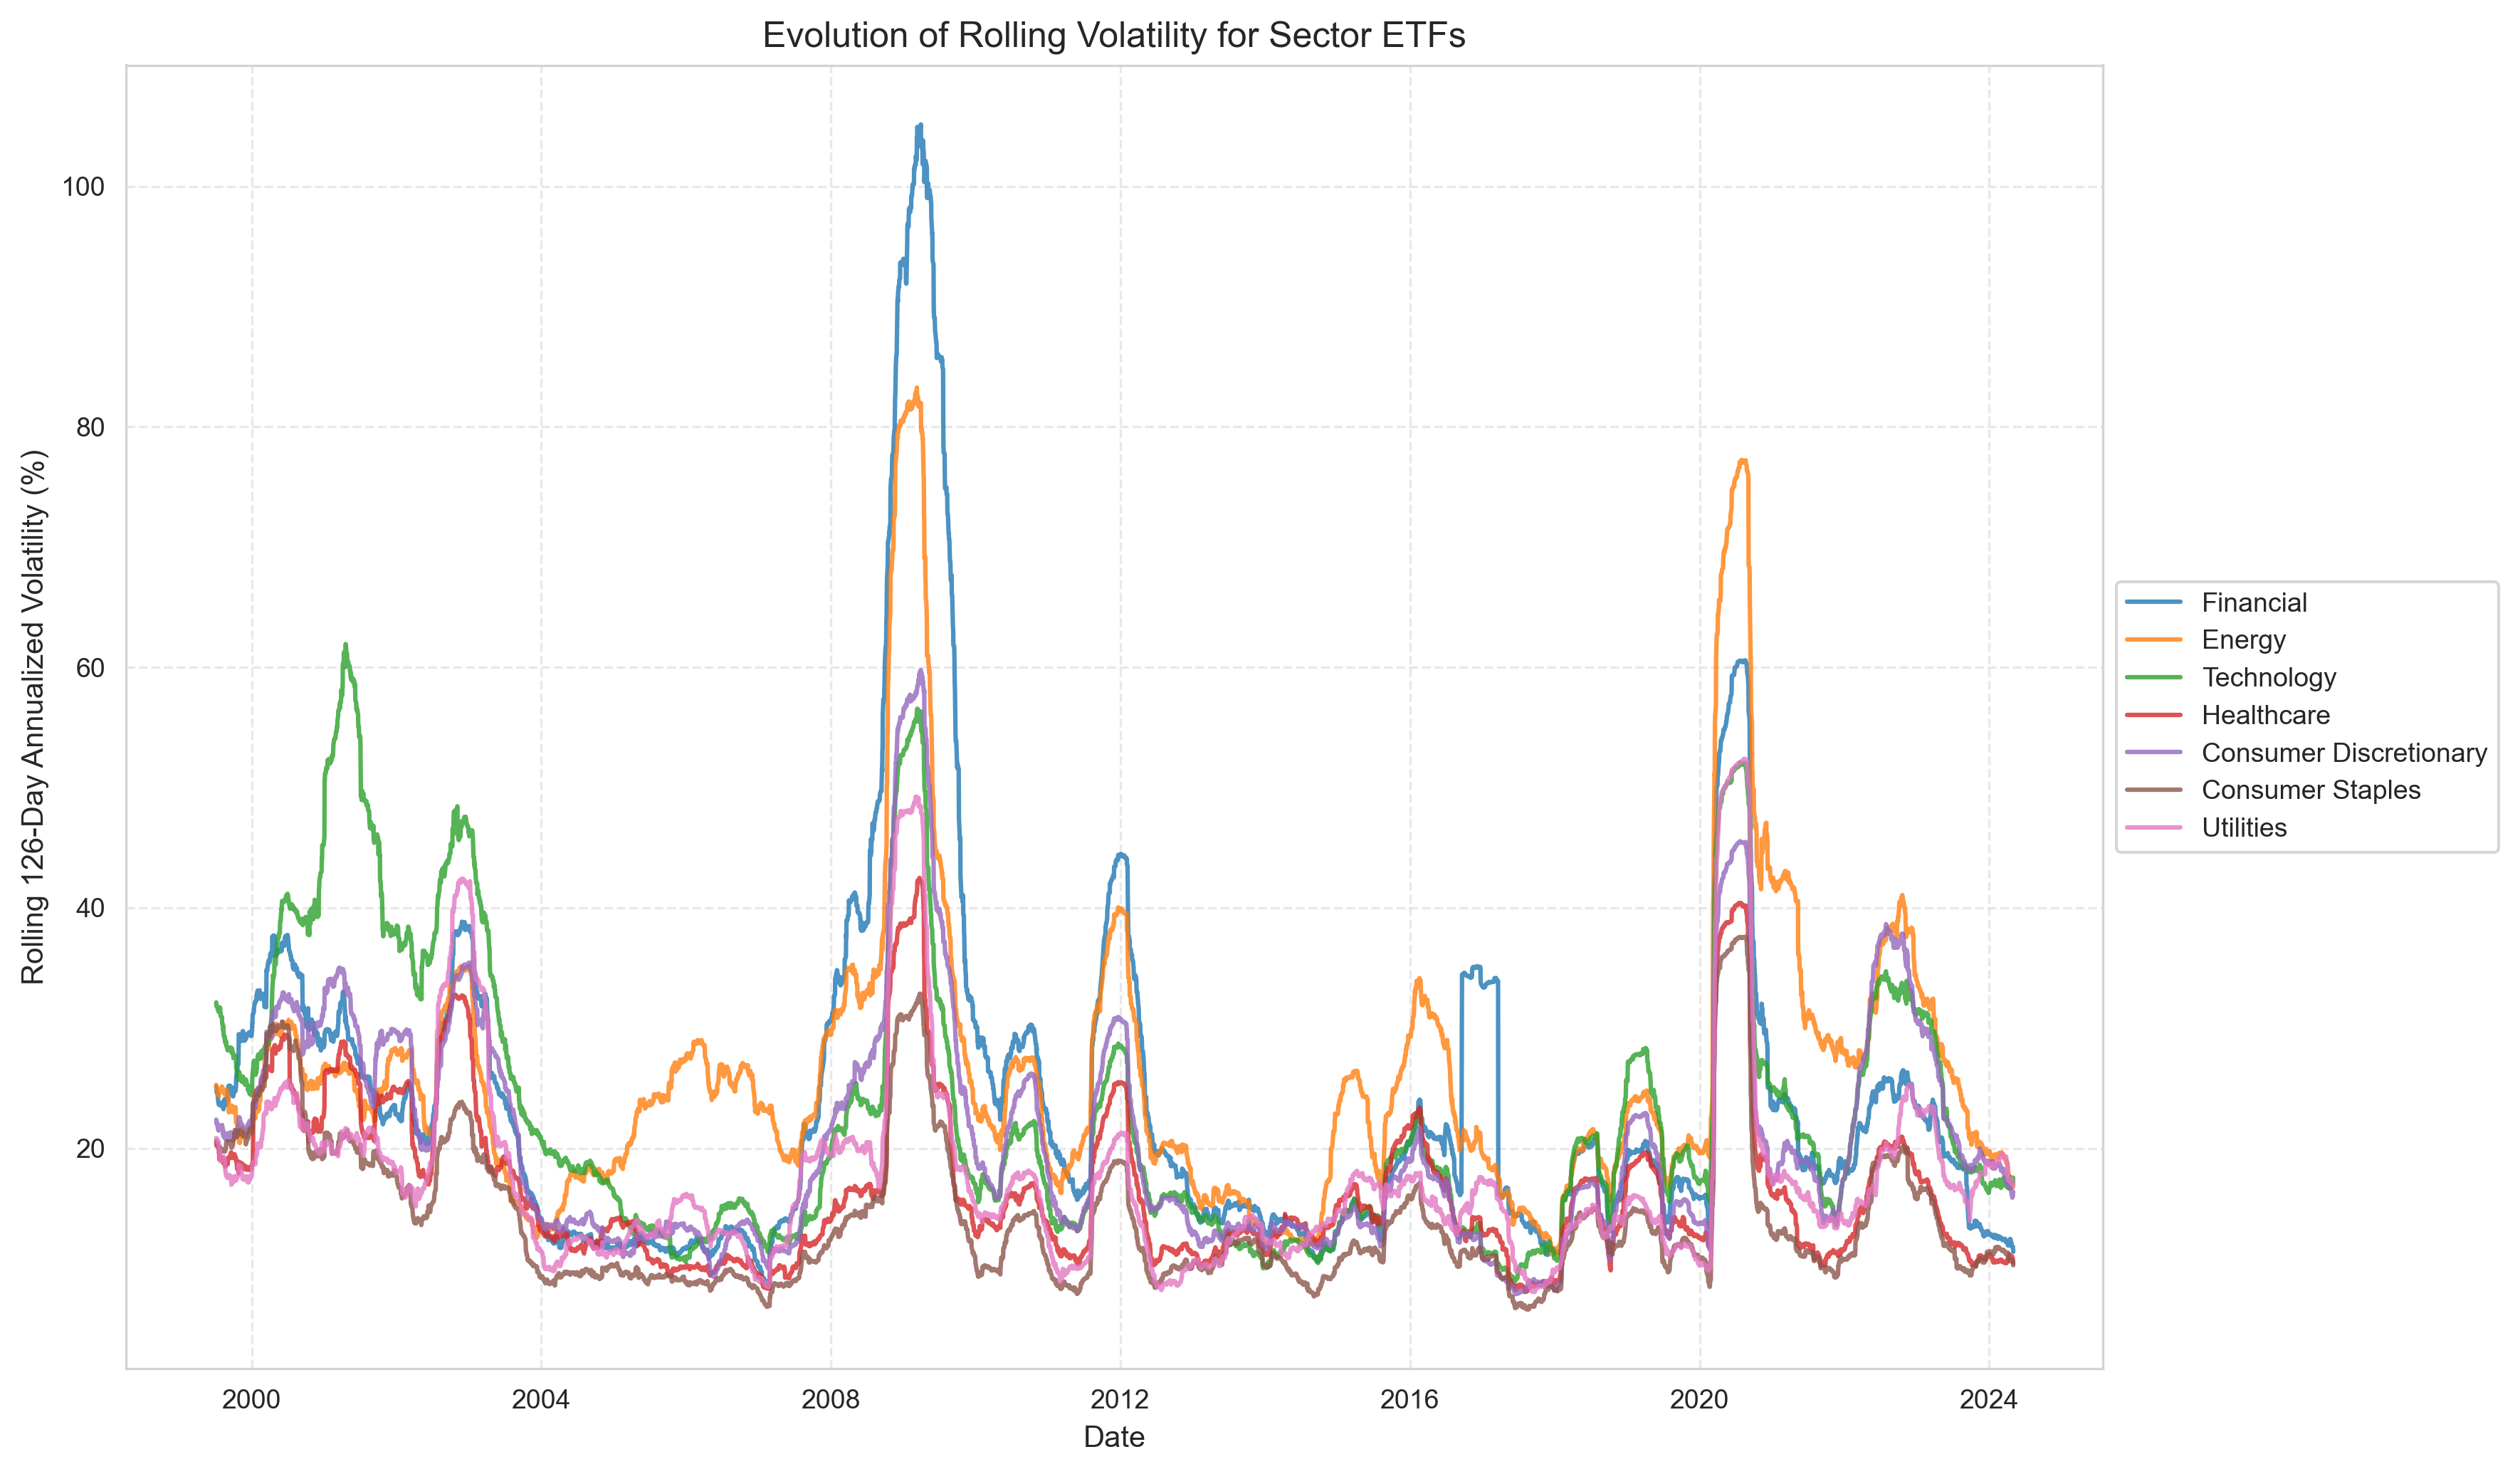

In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import traceback

# --- Configuration ---

# 1. Define Asset Group
SECTOR_ETFS = {
    'Financial': 'XLF.US',
    'Energy': 'XLE.US',
    'Technology': 'XLK.US',
    'Healthcare': 'XLV.US',
    'Consumer Discretionary': 'XLY.US',
    'Consumer Staples': 'XLP.US',
    'Utilities': 'XLU.US'
}

# 2. Define Overall Period for Fetching Data (covering the full history you want to analyze)
#    This should encompass the entire history of the ETFs you're interested in.
#    The MarketDataProcessor will fetch data within this range.
#    Individual ETFs might have shorter actual histories within this period.
fetch_start_date = '1999-01-01' # Or earlier if your ETFs have longer history
fetch_end_date = '2024-05-01'   # Current end date

# 3. Rolling Window Parameter
ROLLING_WINDOW_DAYS = 126 # Example: Approx. 6 months of trading days. Adjust as needed (e.g., 63 for ~3mo, 252 for ~1yr)

# 4. Plotting Parameters
group_name_std_rolling = 'Sector ETFs'
# You can select a subset of assets to plot to avoid clutter, or plot all.
assets_subset_std_rolling = None # Example: ['Financial', 'Technology'] or None for all
output_dir_std_rolling = 'output_figures_and_data'
save_fig_std_rolling = True
show_fig_std_rolling = True
min_obs_for_rolling_start = ROLLING_WINDOW_DAYS # Ensure window is full before value is calculated

print(f"\n--- Plotting ROLLING Evolution of Standard Deviation for {group_name_std_rolling} (Window: {ROLLING_WINDOW_DAYS} days) ---")

# --- Prerequisite Check ---
prereqs_met_rolling_std = False
if 'MarketDataProcessor' not in globals():
     print("Error: 'MarketDataProcessor' class not found.")
elif 'client' not in globals() or client is None:
     print("Error: EODHD API client 'client' not found or not initialized.")
else:
     prereqs_met_rolling_std = True

# --- Data Calculation and Plotting ---
if prereqs_met_rolling_std:
    try:
        processor = MarketDataProcessor(api_client=client)
        
        assets_to_plot = list(SECTOR_ETFS.keys())
        if assets_subset_std_rolling:
             assets_to_plot_resolved = [name for name in assets_subset_std_rolling if name in SECTOR_ETFS]
             if not assets_to_plot_resolved:
                  print(f"Warning: None of the specified assets for subset found. Plotting all available.")
             else:
                  assets_to_plot = assets_to_plot_resolved

        print(f"Calculating rolling standard deviation for assets: {', '.join(assets_to_plot)}")

        # --- Plotting ---
        fig, ax = plt.subplots(figsize=(14, 7)) # Adjusted figsize for time series
        palette = sns.color_palette("tab10", n_colors=len(assets_to_plot))

        for i, asset_name in enumerate(assets_to_plot):
            ticker = SECTOR_ETFS[asset_name]
            print(f"  Processing {asset_name} ({ticker})...")

            price_data = processor.fetch_daily_data(
                ticker,
                fetch_start_date,
                fetch_end_date,
                use_cache=True
            )

            if price_data.empty or len(price_data) < min_obs_for_rolling_start:
                print(f"    Warning: Insufficient price data for {asset_name} (found {len(price_data)} points). Skipping.")
                continue

            returns = processor.calculate_returns(price_data, method='log')
            if returns.empty or len(returns) < min_obs_for_rolling_start:
                 print(f"    Warning: Insufficient returns data for {asset_name} (found {len(returns)} points). Skipping.")
                 continue

            # Calculate rolling standard deviation
            # .dropna() removes the initial NaNs where the window wasn't full
            rolling_std = returns.rolling(window=ROLLING_WINDOW_DAYS, min_periods=ROLLING_WINDOW_DAYS).std().dropna()
            
            # Optionally, convert to daily percentage or annualized percentage for plotting
            # rolling_std_plot = rolling_std * 100 # Daily percentage
            rolling_std_plot = rolling_std * np.sqrt(252) * 100 # Approximate Annualized Percentage Volatility

            if not rolling_std_plot.empty:
                ax.plot(rolling_std_plot.index, rolling_std_plot,
                        linewidth=1.5, alpha=0.8,
                        color=palette[i % len(palette)], label=asset_name)
            else:
                print(f"    Warning: No rolling standard deviation data to plot for {asset_name} after processing.")


        # Customize plot
        ax.set_xlabel('Date')
        ax.set_ylabel(f'Rolling {ROLLING_WINDOW_DAYS}-Day Annualized Volatility (%)') # Adjusted label
        ax.set_title(f'Evolution of Rolling Volatility for {group_name_std_rolling}')
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Handle legend if many lines
        if len(assets_to_plot) <= 10: # Show legend directly if not too many assets
             ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
             plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust for external legend
        else:
             ax.legend(loc='best', fontsize='small') # Or place inside if too many
             plt.tight_layout()

        # Save figure
        if save_fig_std_rolling:
            if not os.path.exists(output_dir_std_rolling):
                try:
                    os.makedirs(output_dir_std_rolling)
                except OSError as e:
                    print(f"Warning: Could not create output directory {output_dir_std_rolling}: {e}")
                    output_dir_std_rolling = '.' # Fallback

            try:
                filename = os.path.join(output_dir_std_rolling, f'rolling_stddev_evolution_{group_name_std_rolling.replace(" ", "_").lower()}_{ROLLING_WINDOW_DAYS}d.png')
                fig.savefig(filename, dpi=300, bbox_inches='tight')
                print(f"Plot saved to: {filename}")
            except Exception as e_save:
                print(f"Error saving rolling std dev plot: {e_save}")

        # Show figure
        if show_fig_std_rolling:
            plt.show()
        else:
            plt.close(fig)

    except Exception as e:
        print(f"An error occurred during rolling standard deviation plotting: {e}")
        traceback.print_exc()
else:
    print("Skipping rolling standard deviation evolution plot due to missing prerequisites.")

# GRACH thing

In [12]:
import pandas as pd
import numpy as np

def print_garch_model_summary_for_ai(analysis_results):
    """
    Prints a structured summary of all GARCH models estimated in the analysis results.
    This output is designed to be easily parsable.

    Args:
        analysis_results (dict): The master dictionary containing results from 
                                 MarketDataProcessor.run_complete_analysis().
    """
    print("=" * 80)
    print("COMPREHENSIVE GARCH MODEL ESTIMATION SUMMARY")
    print("=" * 80)

    if not analysis_results or 'asset_results' not in analysis_results:
        print("No analysis results found or 'asset_results' key is missing.")
        return

    for asset_display_name, asset_data in analysis_results['asset_results'].items():
        print(f"\n--- Asset: {asset_display_name} (Ticker: {asset_data.get('ticker', 'N/A')}) ---")

        periods_to_check = {}
        if 'garch_models_full_period' in asset_data:
            periods_to_check['Full Period'] = asset_data['garch_models_full_period']
        
        if 'sub_period_analysis' in asset_data:
            for sub_period_name, sub_period_data in asset_data['sub_period_analysis'].items():
                if 'garch_models' in sub_period_data:
                    periods_to_check[sub_period_name] = sub_period_data['garch_models']

        if not periods_to_check:
            print("  No GARCH model results found for this asset.")
            continue

        for period_name, garch_models in periods_to_check.items():
            print(f"\n  -- Period: {period_name} --")
            
            if isinstance(garch_models, dict) and 'error' in garch_models:
                print(f"    GARCH estimation for this period resulted in an error: {garch_models['error']}")
                continue
            
            if not isinstance(garch_models, dict) or not garch_models:
                print("    No GARCH models dictionary found or it's empty for this period.")
                continue

            # Filter out the 'best_model_overall' summary key if it exists at this level,
            # as we are iterating through individual model fits.
            model_spec_keys = [key for key in garch_models.keys() if key != 'best_model_overall']

            if not model_spec_keys:
                print("    No individual GARCH model specifications found for this period.")
                if 'best_model_overall' in garch_models and garch_models['best_model_overall']:
                     print(f"    Best model identified: {garch_models['best_model_overall'].get('name', 'Unknown')}")
                elif 'best_model_overall' in garch_models and not garch_models['best_model_overall']:
                    print("    No best GARCH model was identified (e.g., all failed).")

            for model_spec_name in model_spec_keys:
                model_details = garch_models[model_spec_name]
                print(f"\n    Model Specification: {model_spec_name}")

                if isinstance(model_details, dict) and 'error' in model_details:
                    print(f"      Status: ERROR")
                    print(f"      Error Type: {model_details.get('error_type', 'N/A')}")
                    print(f"      Error Message: {model_details.get('error_message', 'N/A')}")
                elif isinstance(model_details, dict):
                    print(f"      Status: Success")
                    print(f"      Log-Likelihood: {model_details.get('loglikelihood', np.nan):.4f}")
                    print(f"      AIC: {model_details.get('aic', np.nan):.4f}")
                    print(f"      BIC: {model_details.get('bic', np.nan):.4f}")
                    print(f"      Persistence (Approx): {model_details.get('persistence', np.nan):.4f}")
                    
                    parameters = model_details.get('parameters', {})
                    if parameters:
                        print("      Parameters:")
                        for param_name, param_value in parameters.items():
                            # Try to get p-value if available
                            p_value = model_details.get('pvalues', {}).get(param_name, np.nan)
                            print(f"        {param_name}: {param_value:.4f} (p-value: {p_value:.4f})")
                    else:
                        print("      Parameters: Not available")
                    
                    # Print distribution-specific parameters if they exist and were stored
                    if 'nu' in model_details: # For studentst, skewstudent
                         print(f"        nu (DoF/Shape): {model_details['nu']:.4f} (p-value: {model_details.get('pvalues', {}).get('nu', np.nan):.4f})")
                    if 'lambda' in model_details: # For skewstudent
                        print(f"        lambda (Skew): {model_details['lambda']:.4f} (p-value: {model_details.get('pvalues', {}).get('lambda', np.nan):.4f})")

                else:
                    print(f"      Model details in unexpected format: {type(model_details)}")
            
            # Print summary of the best model for the period if available
            if 'best_model_overall' in garch_models and garch_models['best_model_overall'] and isinstance(garch_models['best_model_overall'], dict):
                best_model_info = garch_models['best_model_overall']
                print(f"\n    --- Best Model for '{period_name}' (by AIC) ---")
                print(f"      Name: {best_model_info.get('name', 'Unknown')}")
                print(f"      Log-Likelihood: {best_model_info.get('loglikelihood', np.nan):.4f}")
                print(f"      AIC: {best_model_info.get('aic', np.nan):.4f}")
                print(f"      BIC: {best_model_info.get('bic', np.nan):.4f}")
                parameters = best_model_info.get('parameters', {})
                if parameters:
                    print("      Parameters (Best Model):")
                    for param_name, param_value in parameters.items():
                         p_value = best_model_info.get('pvalues', {}).get(param_name, np.nan)
                         print(f"        {param_name}: {param_value:.4f} (p-value: {p_value:.4f})")
            elif 'best_model_overall' in garch_models and not garch_models['best_model_overall']:
                 print(f"\n    --- No best GARCH model identified for '{period_name}' (e.g., all failed or no successful fits). ---")


    print("\n" + "=" * 80)
    print("END OF GARCH MODEL SUMMARY")
    print("=" * 80)

# Example usage (assuming your results are in a variable named `master_results_indices` 
# or `master_results_equities` etc., from your notebook):

# master_results_indices = # ... your results from run_complete_analysis for indices
# print_garch_model_summary_for_ai(master_results_indices)

# master_results_equities = # ... your results from run_complete_analysis for equities
# print_garch_model_summary_for_ai(master_results_equities)

# Or if you have a single combined dictionary:
# combined_analysis_results = {**master_results_indices, **master_results_equities} # This might need adjustment based on your actual structure
# print_garch_model_summary_for_ai(combined_analysis_results) # if your structure is {analysis_name: {asset_results: ...}}

# If your top-level result from run_complete_analysis is directly the dictionary
# that has 'asset_results' (e.g., result_sp500 = processor.run_complete_analysis(...)), then:
# print_garch_model_summary_for_ai(result_sp500) 